# Mixed layer heat budget analysis of ACCESS-OM2 runs

This notebook contains a quick analysis of the mixed layer heat budget in ACCESS-OM2, using online heat budget diagnostics.

## Background Theory and diagnostics

### ACCESS-OM2 "Eulerian" heat budget

The budget for temperature within a single grid-cell can be formulated as:

\begin{equation}
    \frac{\partial}{\partial t}\left(\int_R \rho_0 C dV\right) = -\oint_{\partial R} \left[\rho_0 C (\mathbf{v} - \mathbf{v}^{(b)}) + \mathbf{J}\right]\cdot\mathbf{\hat{n}}\,d\mathcal{S},
\end{equation}

where $R$ represents the grid cell region, $C$ is the tracer concentration $=C_p \Theta$ for temperature, $\mathbf{\hat{n}}$ is the outward normal vector on the boundary surface $\partial R$, $d\mathcal{S}$ is the area element on that boundary, $\mathbf{v}$ is the fluid velocity, $\mathbf{v}^{(b)}$ is the velocity of the boundary and $\mathbf{J}$ represents tracer fluxes across the boundary surface associated with sub-grid scale parameterizations (such as vertical mixing) and boundary fluxes (such as air-sea tracer fluxes).

The equivalent equation in terms of MOM5 diagnostics (per unit area) is given by:
\begin{align}
  \textit{temp\_tendency} = &\textit{temp\_advection} + \\ &\quad +
  \textit{temp\_submeso} \\ &\quad + \textit{temp\_vdiffuse\_diff\_cbt}  + \textit{temp\_nonlocal\_KPP} \\ &\quad + \textit{sw\_heat} +
  \textit{temp\_rivermix} + \textit{temp\_vdiffuse\_sbc} + \textit{sfc\_hflux\_pme} \\
  & \quad + \textit{frazil\_3d}\\ 
   & \quad + \textit{temp\_vdiffuse\_k33} + \textit{neutral\_diffusion\_temp}\\
   & \quad + \textit{neutral\_gm\_temp} \\
   & \quad + \textit{mixdownslope\_temp} + \textit{temp\_sigma\_diff} + \textit{temp\_eta\_smooth}
\end{align}

All terms are in units of Wm$^{-2}$ - i.e. the tendency of the heat content within each grid cell per unit area, $\rho_0 C_p\Theta \Delta z$, where $\Delta z$ is the time variable grid cell thickness, $\rho_0=1035$kgm$^{-3}$ is the reference density, $C_p=3992.10322329649$Jkg$^{-1}$$^\circ$C$^{-1}$ is the specific heat and $\Theta$ is Conservative Temperature.

- temp\_tendency is the tendency term
- temp\_advection is the convergence of the three-dimensional resolved advection (this can be split into components by taking the convergence of the temp\_xflux\_adv, temp\_yflux\_adv and temp\_zflux\_adv terms). Note that this is equivalent to
\begin{equation}
-\oint_{\partial R - \partial\eta} \rho_0 C (\mathbf{v} - \mathbf{v}^{(b)})\cdot\mathbf{\hat{n}}\,d\mathcal{S},
\end{equation}
i.e. it does not include the dia-surface motion across the free-surface ($\partial\eta$), which is instead captured by $\textit{sfc\_hflux\_pme}$, equal to $-\oint_{\partial\eta} \rho_0 C (\mathbf{v} - \mathbf{v}^{(b)})\cdot\mathbf{\hat{n}}\,d\mathcal{S}$
- temp\_submeso is the convergence of the three-dimensional parameterized submesoscale advection (pretty small).
- temp\_vdiffuse\_diff\_cbt and temp\_nonlocal\_KPP are the vertical mixing terms.
- The next line contains all of the surface heat flux terms. Note that sw\_heat is a three-dimensional term that *redistributes* the impact of SW radiation from the surface layer into the interior (i.e. it is negative in the surface layer and positive below, summing to zero). temp\_rivermix is also three-dimensional as the impact of river runoff is spread over a few layers (4 I think). The other terms are two-dimensional (only non-zero in the surface layer).
- frazil\_3d is the formation of frazil ice
- temp\_vdiffuse\_k33 and neutral\_diffusion\_temp are parameterized along-isopycnal mixing (might not be on in all configurations, e.g. ACCESS-OM2-01).
- neutral\_gm\_temp is parameterization advection by mesoscale eddies
- The last line includes some miscellaneous mixing terms (all pretty small, and not all active depending on configuration).

Also see https://github.com/COSIMA/access-om2/issues/139#issuecomment-639278547 for a discussion of the surface heat flux terms in ACCESS-OM2/CM2. There are some cells below which check this budget closure.

### Mixed layer temperature budget 

The mixed layer depth is defined as the depth at which the buoyancy difference to from the surface is $0.0003$ms$^{-2}$, corresponding to a density difference of $0.031$kgm$^{-3}$. 
$0.03$kgm$^{-3}$ is a widely used value in the literature. We define the mixed layer in a continuous sense, such that the mixed layer base can lie between two grid cells (linear interpolation), with a known fractional contribution of the bottom grid cell to the mixed layer. The mixed layer within a given model column is defined by the region $\partial R_H$.

We are most interested in the tracer concentration averaged over the mixed layer volume, rather than the total mixed layer tracer content.
We define this (for temperature) as,
\begin{equation}
    \Theta_H \equiv \frac{1}{H}\int_{-H_z}^\eta \Theta dz,
\end{equation}
where $\eta$ is the free-surface height and $H_z$ is the depth of the mixed layer (from $z=0$), such that the total mixed layer depth is $H=\eta+H_z$.

A bunch of maths, shown elsewhere (paper in preparation), shows that $\Theta_H$ obeys the budget equation,

\begin{align}
        \frac{\partial \Theta_H}{\partial t}&= \quad\quad &\quad\quad\text{tendency}\\ &\quad-\frac{1}{AH}\oint_{\partial R_H - \partial\eta} \left(\Theta-\Theta_H\right) \mathbf{v}\cdot\mathbf{\hat{n}}\,d\mathcal{S}-\frac{Q_{\text{L}}}{\rho_0 H}\quad\quad &\quad\quad\text{advection (+ eddy processes)} \\
        &\quad+\frac{Q_\text{net}}{\rho_0 H}-\frac{\Theta_a - \Theta_H}{\rho_0H}Q_m\quad\quad &\quad\quad\text{surface fluxes} \\
        &\quad-\frac{Q_{\text{SWP}}}{\rho_0 H}\quad\quad &\quad\quad\text{shortwave penetration} \\
        &\quad-\frac{Q_\text{mix}}{\rho_0 H}\quad\quad &\quad\quad\text{vertical mixing} \\
        &\quad-\frac{\Theta_{\text{ent}}-\Theta_H}{H}\frac{\partial H_z}{\partial t}\quad\quad &\quad\quad\text{entrainment}
\end{align}
where $A$ is the area of the grid cell and other terms are described below, in order.

#### Term 1: 
The first line is the tendency term. Note that this term is not a diagnostic in MOM5 (it is not temp\_tendency, which is the tendency of the total heat content of the grid cells making up the mixed layer, $R_{\Sigma G}$ in the paper) and needs to be computed offline using the mixed layer temperature diagnostic.

#### Term 2: 
The second line represents advection and eddy driven processes. This term is effectively equal to $\textit{temp\_advection} + \textit{temp\_submeso} + \textit{temp\_vdiffuse\_k33} + \textit{neutral\_diffusion\_temp} + \textit{neutral\_gm\_temp}$ divided by $C_p\rho_0 H$, except that since $H$ is time-varying, this division needs to be done online at every time-step. This is done by the new diagnostics $\textit{temp\_advection\_in\_mld}$ (and equivalent for the eddy terms), which are equal to $\textit{temp\_advection}/H$ summed over the mixed layer (so divide these by $\rho_0 C_p$ to get the above equation). Hwoever, we also note that more maths (see the appendix of the paper), shows that two additional correction terms,
\begin{equation}
\frac{\Theta_H}{H}\nabla\cdot\mathbf{U} - \frac{\Theta_{\text{ent}}}{H} w^{(s)}_H \quad\quad\quad\text{(TO COMPUTE!!!)}
\end{equation}
need to be added to $\textit{temp\_advection\_in\_mld}/\rho_0/C_p$ in order to get the advection term in the above equation to account for the fact that the advection diagnostic temp\_advection is computed in GVC coordinates, not Eulerian coordinates. $\nabla\cdot\mathbf{U}$ represents the divergence of the vertically-integrated transport (throughout the whole ocean depth) and $w^{(s)}_H$ represents the motion of the GVC coordinates at the base of the mixed layer (easily computable from $\partial\eta/\partial t$). The later of these should be small. Also worth noting that both of these terms are dependent on the temperature scale, and thus remove the dependence of the temperature scale in $\textit{temp\_advection\_in\_mld}$.

#### Term 3: 
The third line represents surface fluxes, including the terms $\textit{temp\_vdiffuse\_sbc\_in\_mld} + \textit{sfc\_hflux\_pme\_in\_mld} + \textit{frazil\_3d\_in\_mld} + \textit{temp\_rivermix\_in\_mld}$ divided by $\rho_0 C_p$. The second part of this term in the above equation accounts for the impact of surface mass fluxes, $Q_m$ (in kgs$^{-1}$), where $C_a$ is the tracer concentration of the added (or removed) surface mass. For temperature in MOM5, $C_a$ is equal to the temperature of the top grid cell. In this term, another correction needs to be added to the existing online diagnostics, 
\begin{equation}
\Theta_H Q_m/(\rho_0 H).\quad\quad\quad\text{(TO COMPUTE!!!)}
\end{equation} 
Again, due to the fact that $Q_m$, $\Theta_H$ and $H$ all vary in time, this term needs to be computed online. Note that for simplicity (and because its tiny) we include $\textit{temp\_eta\_smooth\_in\_mld}$ in this term as well.

#### Term 4: 
The fourth line represents shortwave penetration, simply equal to $\textit{sw\_heat\_in\_mld}/\rho_0/C_p$.

#### Term 5: 
The fifth line represents vertical mixing at the base of the mixed layer, equal to $(\textit{temp\_vdiffuse\_diff\_cbt\_in\_mld}  + \textit{temp\_nonlocal\_KPP\_in\_mld})/\rho_0/C_p$.

#### Term 6: 
The last line represents entrainment, where $\Theta_\text{ent}$ is the temperature of the entrained water. This is not an explicit diagnostic in MOM5 (computing $\Theta_{\text{ent}}$ would be tricky). So here, we compute it as the residual of the budget above.

Note that the term $\textit{temp\_tendency\_in\_mld}$ is the sum of all the \_in\_mld terms, which represents (apart from the 3 corrections above) the tendency in the heat content of the layer ignoring the extra heat content entering through entrainment. Hence (again ignoring the 3 corrections noted above) entrainment effectivley represents the difference between $\textit{temp\_tendency\_in\_mld}$ and $\partial \Theta_H/\partial t$.

#### On the corrections
None have been computed as yet (Jan 2025). The first part of the advection one, and the P-E+R one, just correspond to terms in the free-surface evolution equation
\begin{equation}
\frac{\partial \eta}{\partial t} = \nabla\cdot\mathbf{U} + Q_m/\rho_0
\end{equation}
multiplied by $\Theta_H/H$. The term dependent on $w^{(s)}_H$ is hard to compute (depends on $\Theta_{\text{ent}}$) and so we'll probably ignore it...

## Hat averaging

The following material comes from Bladwell et al. (2025, in prep.). Consider a variable $\xi(t)$ (e.g. mixed layer temperature at a single location), defined as a function of time. We will consider two ``epochs" defined by the time periods $t\in(t_1,t_1+\Delta t_1)$ and  $t\in(t_2,t_2+\Delta t_2)$. The standard average of the tendency of $\xi$ between $t_1$ and $t_2+\Delta t_2$ (i.e. over the entire period covered by standard tendency diagnostics), multiplied by the time gap between them, is given by:
\begin{equation}
(t_2+\Delta t_2 - t_1)\overline{\frac{\partial\xi}{\partial t}}^{t_1,t_2+\Delta t_2} \equiv \int_{t_1}^{t_2+\Delta t_2} \frac{\partial\xi}{\partial t} dt = \left[\xi(t_2+\Delta t_2) - \xi(t_1)\right]
\end{equation}
This corresponds to a difference in snapshots of $\xi$, and thus is not typically a quantity of interest.

Instead, we define the "hat average" operator between the two epochs as,
\begin{equation}
\hat{\frac{\partial\xi}{\partial t}}^{t_1,t_1+\Delta t_1,t_2,t_2+\Delta t_2} \equiv \int_{t_1}^{t_1+\Delta t_1} \frac{t-t_1}{\Delta t_1}\frac{\partial\xi}{\partial t} dt + \int_{t_1+\Delta t_1}^{t_2} \frac{\partial\xi}{\partial t} dt + \int_{t_2}^{t_2+\Delta t_2} \frac{t_2+\Delta t_2 - t}{\Delta t_2}\frac{\partial\xi}{\partial t} dt = \overline{\xi}^{t_2,t_2+\Delta t_2} - \overline{\xi}^{t_1,t_1+\Delta t_1}
\end{equation}
This corresponds to a "rising average" over the first epoch, and standard average between them, and a falling average over the second epoch (hence the "hat average"). Evidently, the hat average between the two epochs is the operation needed to relate the tendency $\partial\xi/\partial t$ to the difference between the values of $\xi$ averaged over the two epochs.

Note that the diagnostics output from MOM5 to form the hat averaging correspond to standard, rising and falling averages over a shorter, pre-defined time period (below daily) that does not usually correspond to the epoch differences of interest (e.g. differences between months). If our longer epoch of interest, say $t\in(t_1,t_1+\Delta t_1)$, consists of $N$ sections of shorter diagnostics of length $\Delta t$ (e.g. the month of January consists of $N=31$ sections of length $\Delta t=1$ day, with $\Delta t_1=N\Delta t$), then we can use the following formula's to compute the rising "difference" (i.e. the first term in the previous equation) over the longer (i.e. entire January) period from the rising averages over each day,
\begin{equation}
\int_{t_1}^{t_1+N\Delta t} \frac{t-t_1}{N\Delta t} \frac{\partial\xi}{\partial t}dt = \sum_{n=1}^N \frac{1}{N} \int_{t_1+(n-1)\Delta t}^{t_1+n\Delta t} \frac{t-(t_1+(n-1)\Delta t)}{\Delta t} \frac{\partial\xi}{\partial t} dt + \sum_{n=1}^N \frac{(n-1)}{N} \int_{t_1+(n-1)\Delta t}^{t_1+n\Delta t} \frac{\partial\xi}{\partial t} dt
\end{equation}
where the LHS represents the long rising difference over the period $t\in(t_1,t_1+\Delta t_1)$, the first term on the RHS is the sum of $1/N$ times the short rising difference over the short period plus $(n-1)/N$ times the short standard difference over the short period.
The long standard difference is trivially,
\begin{equation}
\int_{t_1}^{t_1+N\Delta t} \frac{\partial\xi}{\partial t}dt = \sum_{n=1}^N \int_{t_1+(n-1)\Delta t}^{t_1+n\Delta t} \frac{\partial\xi}{\partial t} dt
\end{equation}
the long falling difference can be computed as the difference between the two previous equations
\begin{equation}
\int_{t_1}^{t_1+N\Delta t} \frac{t_1 + N\Delta t - t}{N\Delta t} \frac{\partial\xi}{\partial t}dt = \int_{t_1}^{t_1+N\Delta t} \frac{\partial\xi}{\partial t}dt - \int_{t_1}^{t_1+N\Delta t} \frac{t-t_1}{N\Delta t} \frac{\partial\xi}{\partial t}dt
\end{equation}


In [1]:
#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import cftime
from tqdm import tqdm

import cmocean as cm
import sys, os
import datetime

from dask.distributed import Client

In [2]:
# Load workers:
client = Client(n_workers=7)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43217,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 7
Started: Just now,Total memory: 32.00 GiB
Comm: tcp://127.0.0.1:34255,Total threads: 1
Dashboard: /proxy/34687/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:39821,


In [3]:
# Chdir for figure saving:
os.chdir('access-om2-analysis/access-om2-sst-budget')

# Load datasets:

### Define paths, regions and times:

In [4]:
# Testing run:
#base = '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf/'
#base = '/g/data/e14/rmh561/access-om2/archive/025deg_jra55_iaf_online_mlt_testing/'
# output = 372

# Production run:
base = '/g/data/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/'
output = 364

base2 = base + 'output%03d/ocean/' % output

# Subsample regions:
#reg = [-100, 20, 0, 60] # North Atlantic
#reg = [-100, -40, 0, 30] # North Atlantic
#reg = [-230, -190, -50, -10] # EAC
reg = [135-360,175-360, -60, -20] # SE Aus (Kajtar et al. 2022)
#reg = [None,None,None,None] # Globe

# Subsample time:
times = slice('2017-09-01',None)
times_snap = slice('2017-09-01',None) #slice(0,32) # Must be either None (for using all times and previous output), or 1 more than times.

### Load grid and set constants:

In [5]:
ds_grid = xr.open_dataset(base2 + 'ocean_grid.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)
rho0 = 1035.
Cp = 3992.10322329649

### Load daily resolution data:

In [6]:
ds_day_budget = xr.open_dataset(base2 + 'ocean_budget_daily.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day_budget_falavg = xr.open_dataset(base2 + 'ocean_budget_daily_risavg.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3])) # While the name is "risavg", in effect this is actually the falling average diagnostics
ds_day = xr.open_dataset(base2 + 'ocean_daily.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))

# Add snapshot from previous output:
# if times_snap == None:
ds_day_snapshot = xr.open_dataset(base2 + 'ocean_snapshot_daily.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day_snapshot_m1 = xr.open_dataset(base2.replace(str(output),str(output-1)) + 'ocean_snapshot_daily.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day_snapshot = xr.concat([ds_day_snapshot_m1.isel(time=-1),ds_day_snapshot],dim='time')
# else:
# ds_day_snapshot = xr.open_dataset(base2 + 'ocean_snapshot_daily.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3])).isel(time=times_snap)

# Fix time variable by decoding time by hand (see https://forum.access-hive.org.au/t/cftime-vs-datetime64-time-encoding-issues-with-access-om2-025-omip-2-run/4085);
ds_day_budget = ds_day_budget.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_budget.time.values]})
ds_day_budget_falavg = ds_day_budget_falavg.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_budget_falavg.time.values]})
ds_day = ds_day.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day.time.values]})
ds_day_snapshot = ds_day_snapshot.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_snapshot.time.values]})

# Fix average_DT by decoding by hand:
ds_day_budget.average_DT.data = ds_day_budget.average_DT*np.timedelta64(1,'D')
ds_day_budget_falavg.average_DT.data = ds_day_budget_falavg.average_DT*np.timedelta64(1,'D')
ds_day.average_DT.data = ds_day.average_DT*np.timedelta64(1,'D')

# Subselect time:
ds_day_budget = ds_day_budget.sel(time=times)
ds_day_budget_falavg = ds_day_budget_falavg.sel(time=times)
ds_day = ds_day.sel(time=times)
ds_day_snapshot = ds_day_snapshot.sel(time=times_snap)

/jobfs/133091540.gadi-pbs/ipykernel_2691483/1000923018.py:14: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_day_budget = ds_day_budget.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_budget.time.values]})
/jobfs/133091540.gadi-pbs/ipykernel_2691483/1000923018.py:15: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by

### Climatology for a few variables:

In [7]:
# Make a simple climatology:
# cd /g/data/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/
# mkdir clim_1980-2009

# fnames = ['output%03d/ocean/ocean_month.nc' % x for x in np.arange(327,357)]
# ' '.join(fnames)

# ncea -v temp_in_mld output327/ocean/ocean_month.nc output328/ocean/ocean_month.nc output329/ocean/ocean_month.nc output330/ocean/ocean_month.nc output331/ocean/ocean_month.nc output332/ocean/ocean_month.nc output333/ocean/ocean_month.nc output334/ocean/ocean_month.nc output335/ocean/ocean_month.nc output336/ocean/ocean_month.nc output337/ocean/ocean_month.nc output338/ocean/ocean_month.nc output339/ocean/ocean_month.nc output340/ocean/ocean_month.nc output341/ocean/ocean_month.nc output342/ocean/ocean_month.nc output343/ocean/ocean_month.nc output344/ocean/ocean_month.nc output345/ocean/ocean_month.nc output346/ocean/ocean_month.nc output347/ocean/ocean_month.nc output348/ocean/ocean_month.nc output349/ocean/ocean_month.nc output350/ocean/ocean_month.nc output351/ocean/ocean_month.nc output352/ocean/ocean_month.nc output353/ocean/ocean_month.nc output354/ocean/ocean_month.nc output355/ocean/ocean_month.nc output356/ocean/ocean_month.nc clim_1980-2009/ocean_month.temp_in_mld.ncea.nc

In [8]:
# Load climatology of mixed layer temperature:
ds_clim = xr.open_dataset(base + 'clim_1980-2009/ocean_month.temp_in_mld.mld.ncea.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_clim = ds_clim.assign_coords({'time':np.arange(1,13)})

### Load monthly data (usually not used for production runs):

In [46]:
# # monthly data:
# ds_month = xr.open_dataset(base2 + 'ocean_month.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)
# ds_mon_budget = xr.open_dataset(base2 + 'ocean_budget.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)

# if times_snap is None:
#     # Add snapshot from previous output:
#     ds_mon_snapshot = xr.open_dataset(base2 + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
#     ds_mon_snapshot_m1 = xr.open_dataset(base2.replace(str(output),str(output-1)) + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
#     ds_mon_snapshot = xr.concat([ds_mon_snapshot_m1.isel(time=-1),ds_mon_snapshot],dim='time')
# else:
#     ds_mon_snapshot = xr.open_dataset(base2 + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times_snap)

# # Fix time variable by decoding time by hand (see https://forum.access-hive.org.au/t/cftime-vs-datetime64-time-encoding-issues-with-access-om2-025-omip-2-run/4085);
# #for ds in [ds_day_budget,ds_day_budget_falavg,ds_day,ds_day_snapshot]:
# ds_day_budget = ds_day_budget.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_budget.time.values]})
# ds_day_budget_falavg = ds_day_budget_falavg.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_budget_falavg.time.values]})
# ds_day = ds_day.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day.time.values]})
# ds_day_snapshot = ds_day_snapshot.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day_snapshot.time.values]})

# Check that raw budget terms close

## Eulerian budget (no MLD binning):

In [ ]:
# Choose time, region, depth:
time = 0; reg_slice= [-300, 300,-90,90]; st_ocean = 40;

# Load budget:
ds_day_budget_slice = xr.open_dataset(base2 + 'ocean_budget_daily.nc').sel(xt_ocean=slice(reg_slice[0],reg_slice[1]),yt_ocean=slice(reg_slice[2],reg_slice[3])).isel(time=time).isel(st_ocean=st_ocean)

# List the terms:
bud_vars = ['temp_advection','temp_submeso','neutral_diffusion_temp','neutral_gm_temp','temp_vdiffuse_k33',
            'temp_nonlocal_KPP','temp_vdiffuse_diff_cbt',
            'temp_rivermix','temp_vdiffuse_sbc', 'frazil_3d', 
            'sw_heat']

# Add the 2D terms if we're looking at the surface layer:
if st_ocean == 0:
    bud_vars = bud_vars + ['temp_eta_smooth','sfc_hflux_pme']

# Compute the residual:
ds_day_budget_slice['residual'] = ds_day_budget_slice.temp_tendency.load().copy(deep=True)
for var in bud_vars:
    ds_day_budget_slice['residual'] -= ds_day_budget_slice[var].load()

# Add tendency and residual to the terms list:
bud_vars = ['temp_tendency','residual'] + bud_vars

Spatial maximums of terms (Wm-2):
1615.26086,  temp_tendency
   0.00007,  residual
1613.12354,  temp_advection
  10.62282,  temp_submeso
 194.96855,  neutral_diffusion_temp
  79.53624,  neutral_gm_temp
   0.00000,  temp_vdiffuse_k33
   0.00000,  temp_nonlocal_KPP
 107.53768,  temp_vdiffuse_diff_cbt
   0.00000,  temp_rivermix
   0.00000,  temp_vdiffuse_sbc
   0.00000,  frazil_3d
   0.00000,  sw_heat


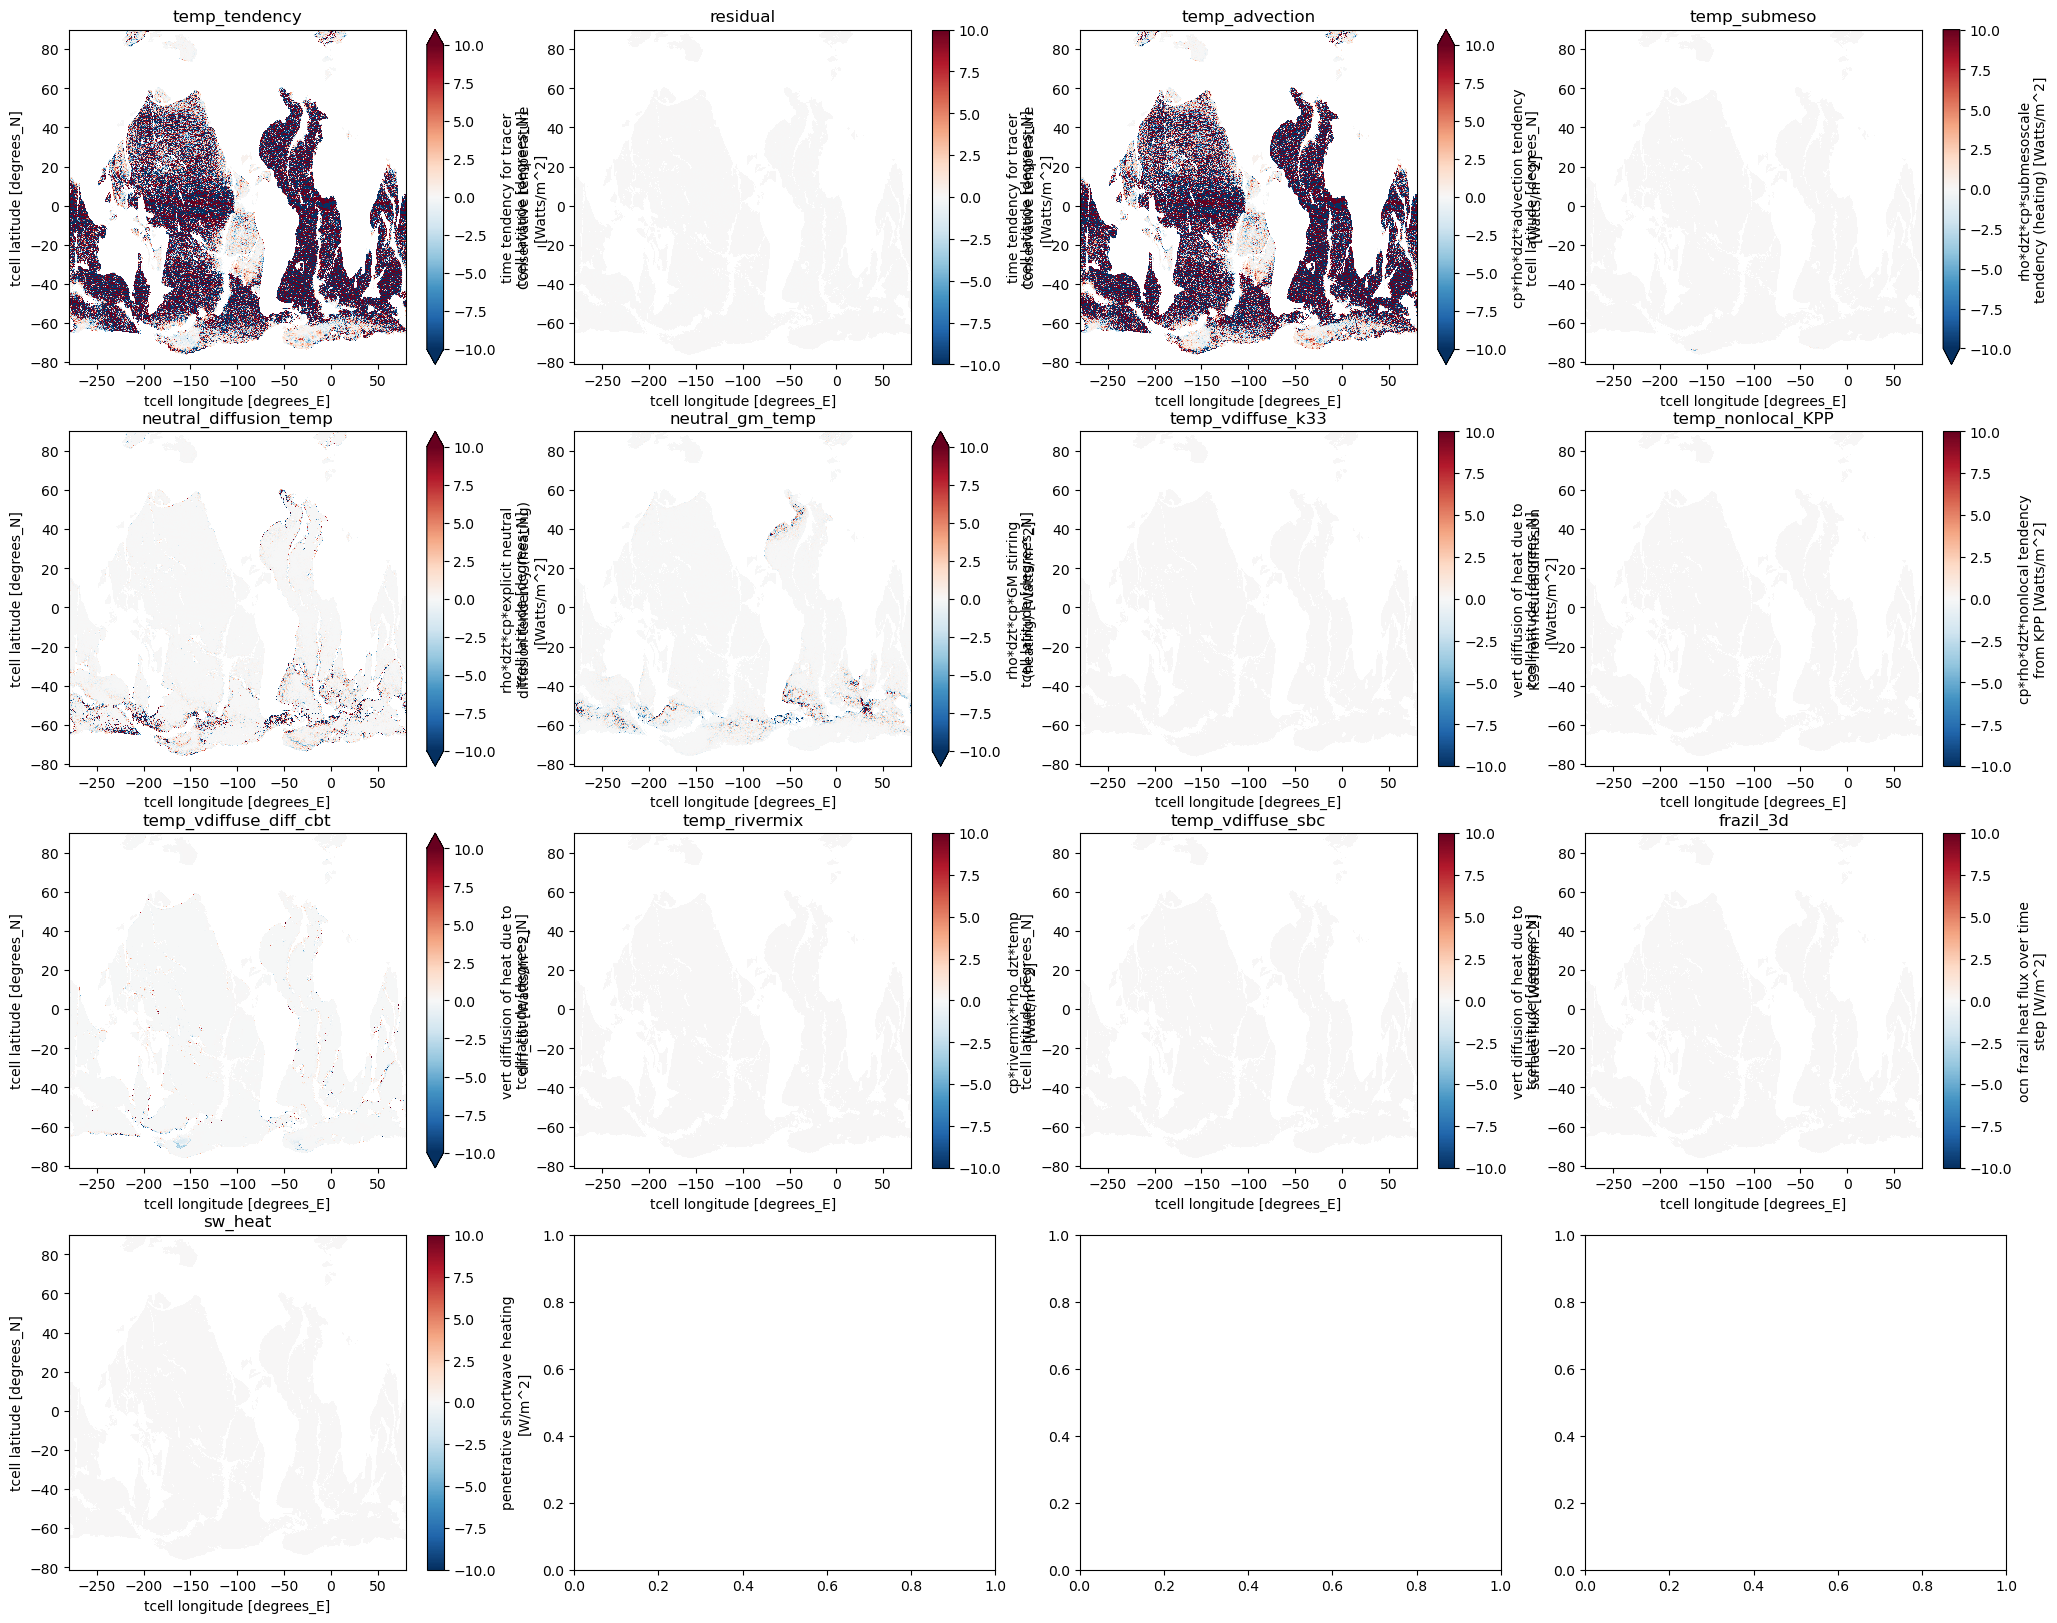

In [8]:
# Plot every term and print out the maximum of the absolute value of every term to confirm closure:
fig, axes = plt.subplots(nrows=4,ncols=4,figsize=(25,20))
axs = axes.reshape(-1)
print('Spatial maximums of terms (Wm-2):')
for i, var in enumerate(bud_vars):
    ds_day_budget_slice[var].plot(ax=axs[i],vmin=-10.,vmax=10.,cmap='RdBu_r')
    axs[i].set_title(var)
    print('%10.5f, ' % (abs(ds_day_budget_slice[var]).max().values) + ' ' + var)


## MLD binned variables (standard and falling averages):

In [11]:
# Choose time and region:
time = 0; reg_slice = [-300, 300,-90,90]#reg = [-100, 20, 0, 60]

# List the terms:
bud_vars = ['temp_tendency_in_mld',
            'sfc_hflux_pme_in_mld','temp_eta_smooth_in_mld','temp_advection_in_mld','temp_submeso_in_mld','neutral_diffusion_in_mld_temp','neutral_gm_in_mld_temp','temp_vdiffuse_k33_in_mld',
            'temp_nonlocal_KPP_in_mld','temp_vdiffuse_diff_cbt_in_mld',
            'temp_rivermix_in_mld','temp_vdiffuse_sbc_in_mld', 'frazil_3d_in_mld', 
            'sw_heat_in_mld']

# Load budget:
# Standard average:
# ds_day_budget_slice = xr.open_dataset(base2 + 'ocean_budget_daily.nc')[bud_vars].sel(xt_ocean=slice(reg_slice[0],reg_slice[1]),yt_ocean=slice(reg_slice[2],reg_slice[3])).isel(time=time)

# Falling average:
ds_day_budget_slice = xr.open_dataset(base2 + 'ocean_budget_daily_risavg.nc')[bud_vars].sel(xt_ocean=slice(reg_slice[0],reg_slice[1]),yt_ocean=slice(reg_slice[2],reg_slice[3])).isel(time=time)/86400.

# Note: For the online-binned budget the 2D terms (temp_eta_smooth and sfc_hflux_pme) are explicitly binned because the mixed layer depth can be less than the depth of the top grid cell (in which case we don't want to take the whole budget term).

# Compute residual:
ds_day_budget_slice['residual_in_mld'] = ds_day_budget_slice.temp_tendency_in_mld.load().copy(deep=True)
for var in bud_vars[1:]:
    ds_day_budget_slice['residual_in_mld'] -= ds_day_budget_slice[var].load()

# Add tendency and residual to budget list:
bud_vars = ['residual_in_mld'] + bud_vars

Spatial maximums of terms (Wm-3):
   0.02789,  residual_in_mld
  65.92769,  temp_tendency_in_mld
  38.74630,  sfc_hflux_pme_in_mld
  11.98063,  temp_eta_smooth_in_mld
 463.29218,  temp_advection_in_mld
  11.90031,  temp_submeso_in_mld
  11.03264,  neutral_diffusion_in_mld_temp
   3.65923,  neutral_gm_in_mld_temp
   0.00003,  temp_vdiffuse_k33_in_mld
  93.03517,  temp_nonlocal_KPP_in_mld
  77.52383,  temp_vdiffuse_diff_cbt_in_mld
 464.02301,  temp_rivermix_in_mld
  50.10825,  temp_vdiffuse_sbc_in_mld
  27.29878,  frazil_3d_in_mld
  22.45745,  sw_heat_in_mld


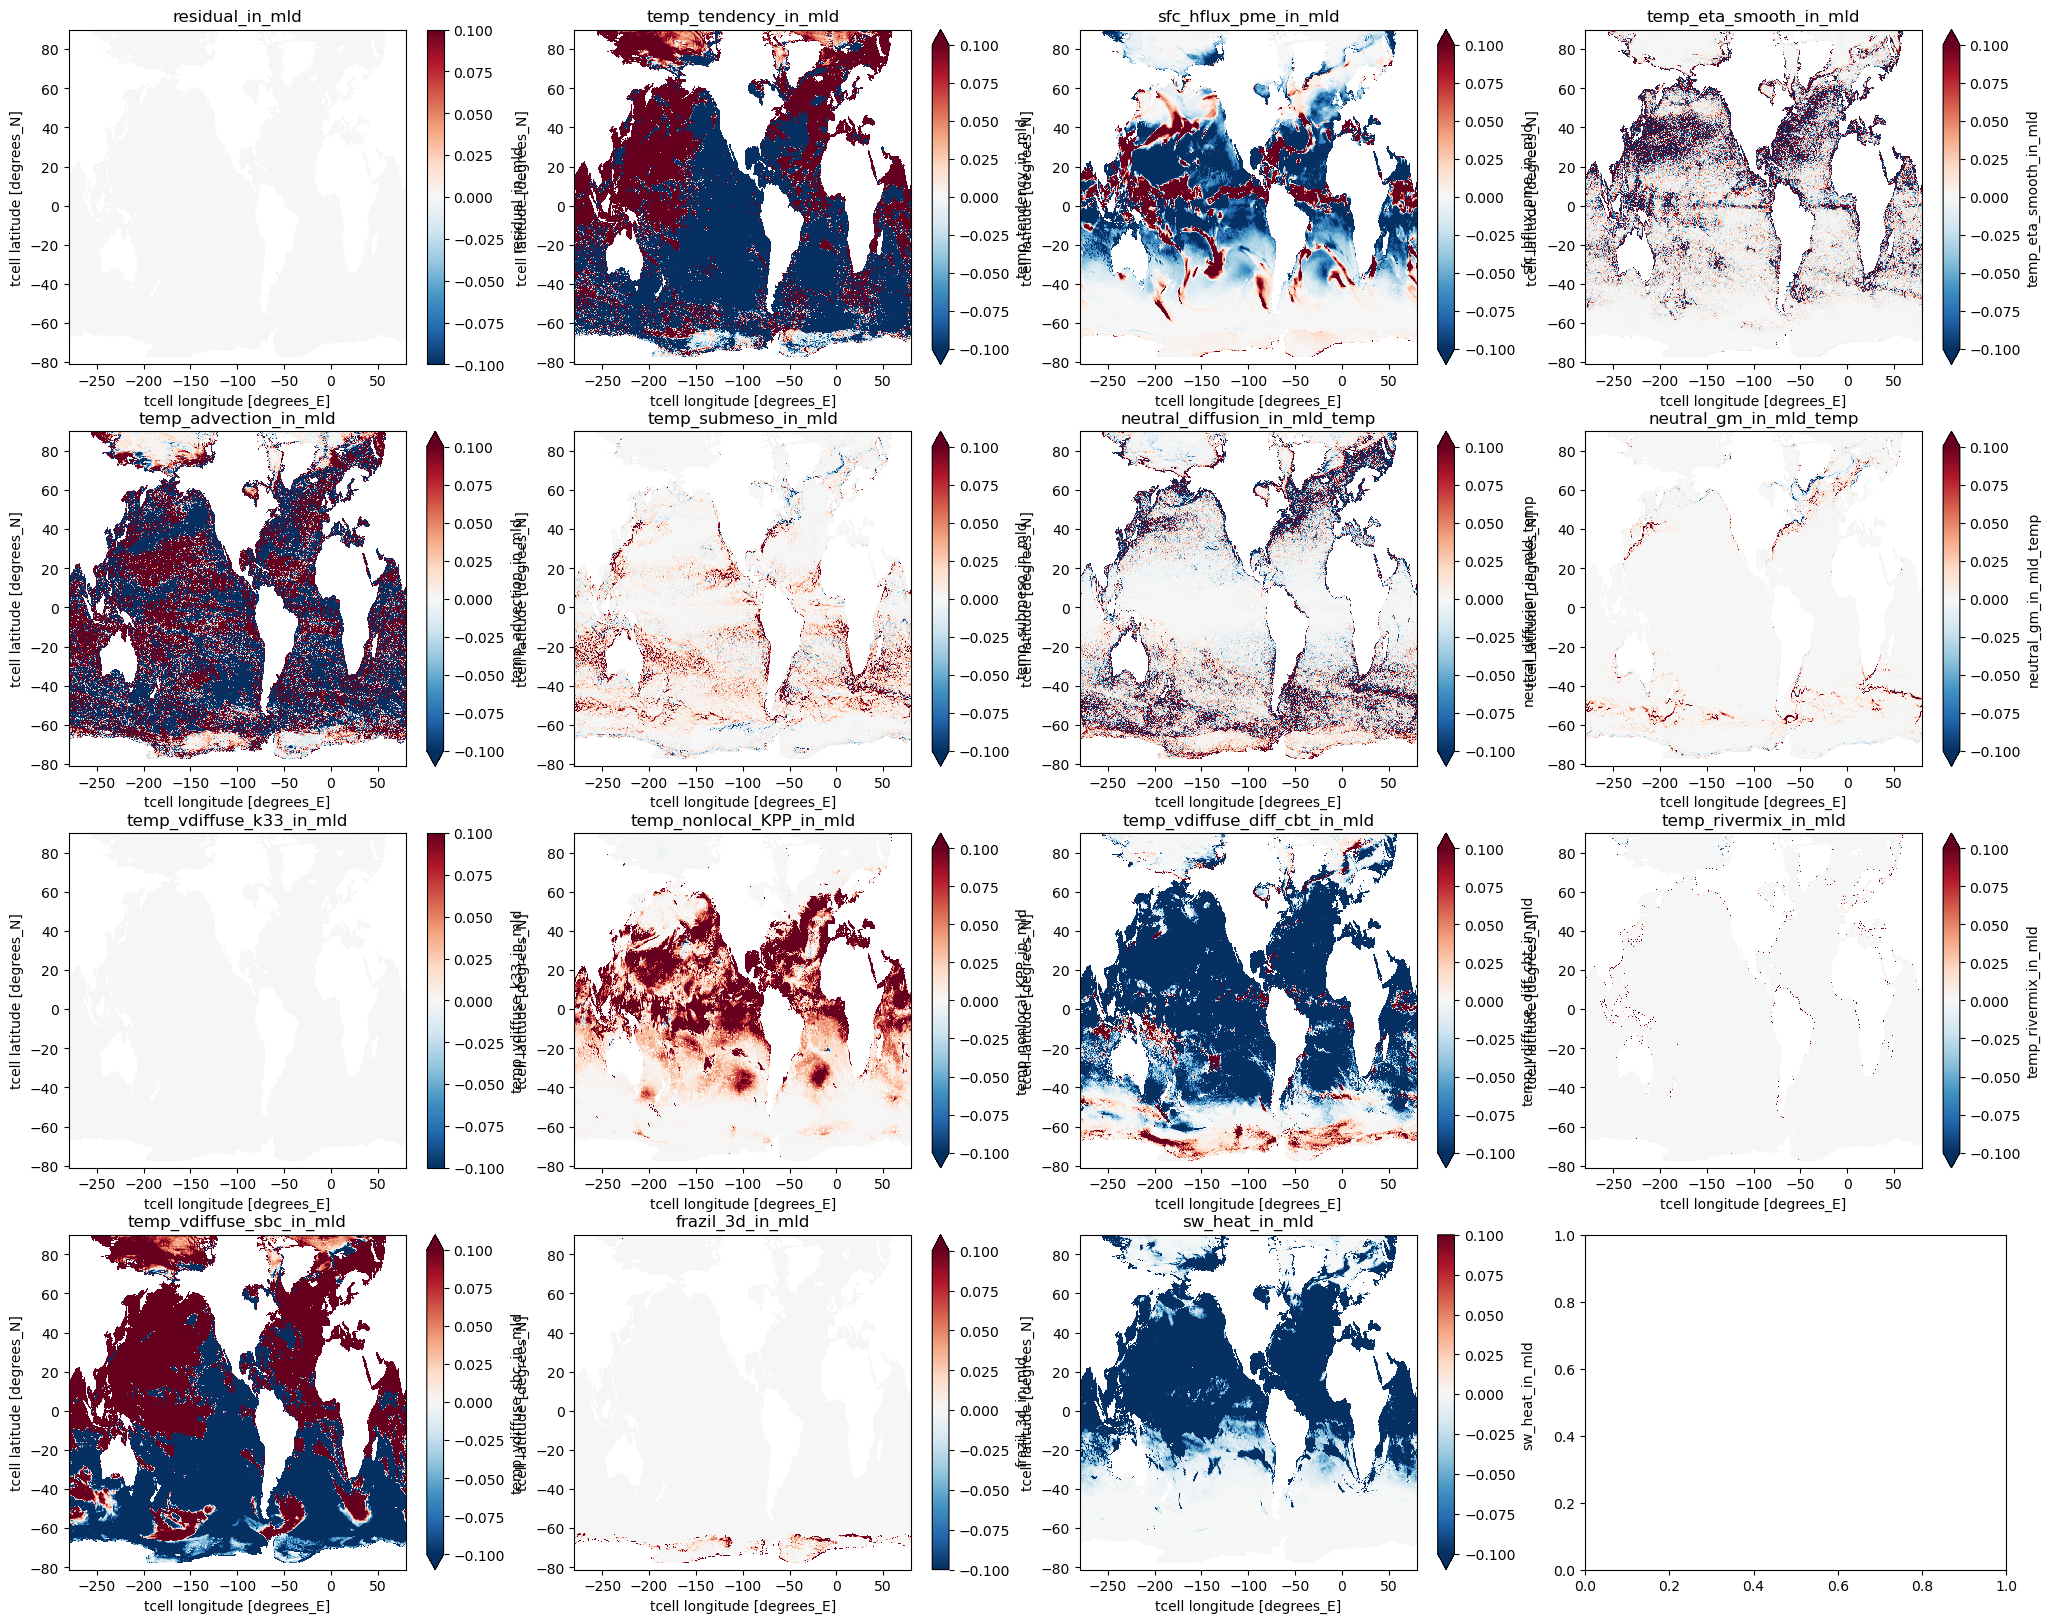

In [12]:
# Plot every term and print out the maximum of the absolute value of every term to confirm closure:
fig, axes = plt.subplots(nrows=4,ncols=4,figsize=(25,20))
axs = axes.reshape(-1)
print('Spatial maximums of terms (Wm-3):')
for i, var in enumerate(bud_vars):
    ds_day_budget_slice[var].plot(ax=axs[i],vmin=-.1,vmax=.1,cmap='RdBu_r')
    axs[i].set_title(var)
    print('%10.5f, ' % (abs(ds_day_budget_slice[var]).max().values) + ' ' + var)


## Bug in temp_mld diagnostic demonstration (see https://github.com/mom-ocean/MOM5/issues/397):

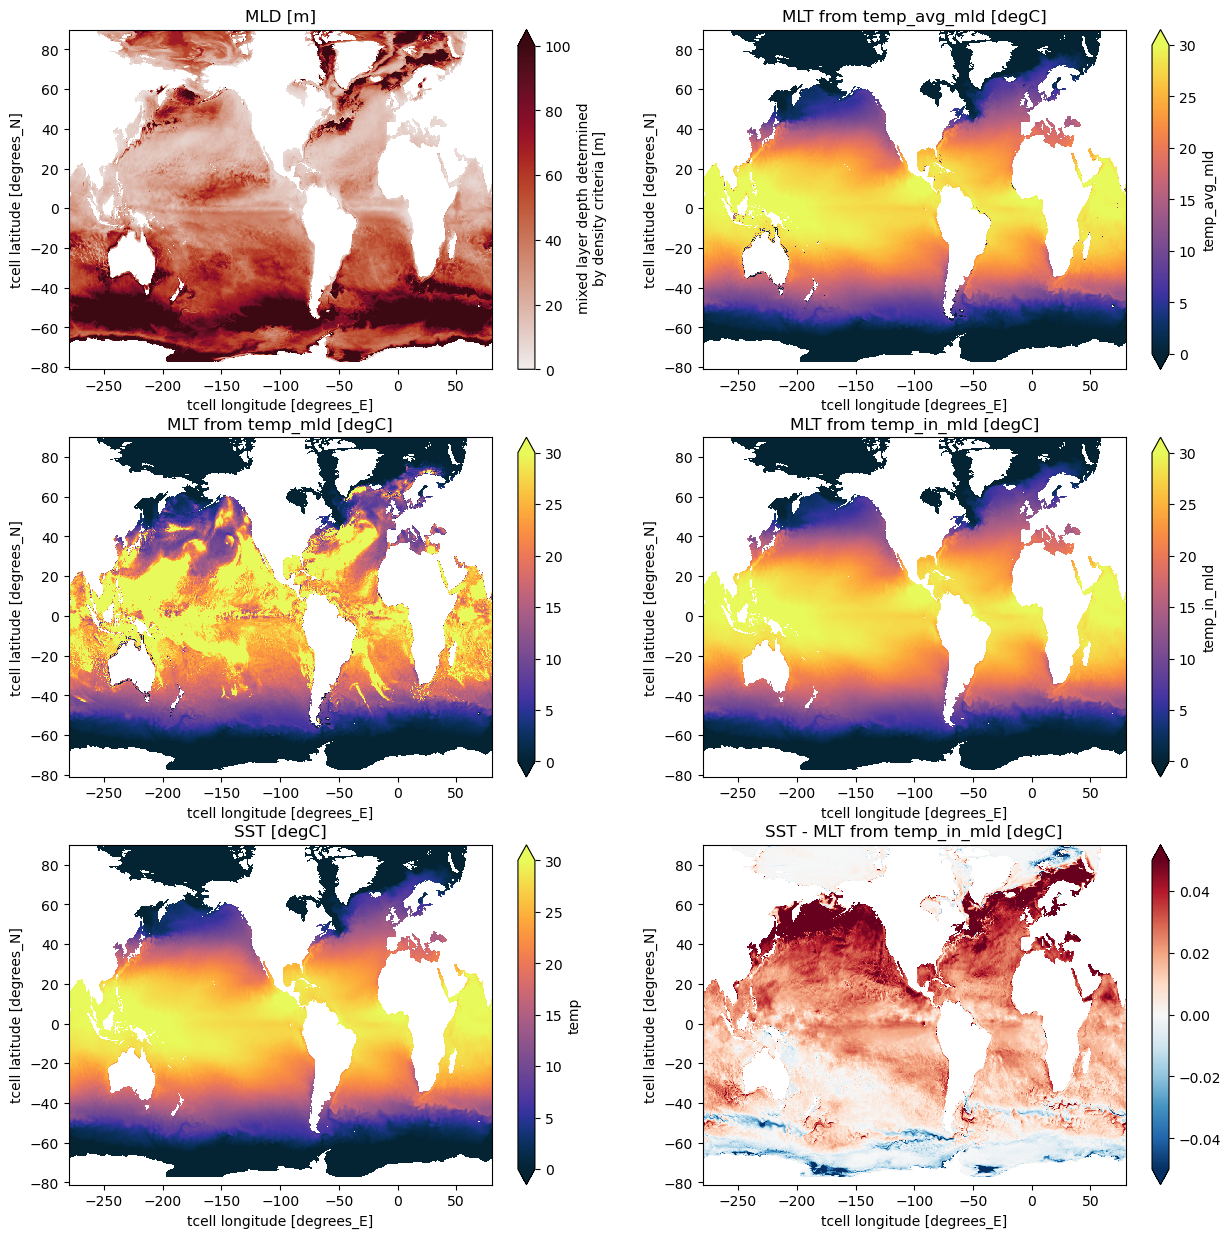

In [43]:
fig,axes = plt.subplots(nrows=3,ncols=2,figsize=(15,15))
(ds_month.mld).isel(time=0).plot(vmin=0.,vmax=100.,ax=axes[0][0],cmap=cm.cm.amp)
axes[0][0].set_title('MLD [m]')
(ds_month.temp_mld/ds_day.mld/rho0).isel(time=0).plot(vmin=0.,vmax=30,ax=axes[1][0],cmap=cm.cm.thermal)
axes[1][0].set_title('MLT from temp_mld [degC]')
(ds_month.temp_avg_mld/rho0).isel(time=0).plot(vmin=0.,vmax=30.,ax=axes[0][1],cmap=cm.cm.thermal)
axes[0][1].set_title('MLT from temp_avg_mld [degC]')
(ds_month.temp_in_mld/rho0).isel(time=0).plot(vmin=0.,vmax=30.,ax=axes[1][1],cmap=cm.cm.thermal)
axes[1][1].set_title('MLT from temp_in_mld [degC]')
(ds_month.temp-273.15).isel(time=0,st_ocean=0).plot(vmin=0.,vmax=30.,ax=axes[2][0],cmap=cm.cm.thermal)
axes[2][0].set_title('SST [degC]')
(ds_month.temp.isel(st_ocean=0)-273.15 - ds_month.temp_in_mld/rho0).isel(time=0).plot(vmin=-0.05,vmax=0.05,ax=axes[2][1],cmap='RdBu_r')
axes[2][1].set_title('SST - MLT from temp_in_mld [degC]')
plt.savefig('temp_mld_diagnostic_checks_global.png',dpi=250)

## Hat-averaging, single-output tendencies check

In [ ]:
# 3D diagnostics:
HC_tend_stavg = ds_day_budget.temp_tendency.isel(st_ocean=0)
HC_tend_falavg = ds_day_budget_falavg.temp_tendency.isel(st_ocean=0)/(ds_day_budget_falavg.average_DT/np.timedelta64(1,'s')) # Division by Dt in seconds required because falling average is an integral not a sum.
HC_tend_risavg = HC_tend_stavg - HC_tend_falavg # Rising average = standard average - falling average

# Time-averaged HC and tendency:
HC = ds_day_budget.temp_rhodzt.isel(st_ocean=0)*Cp
HC_tend_from_HC = HC.diff('time')/86400.
time_cen = [HC.time.isel(time=slice(x,x+2)).mean('time').values for x in range(len(HC.time))][:-1]
HC_tend_from_HC = HC_tend_from_HC.assign_coords({'time':time_cen})

# Time-snapshot HC and tendency:
HC_snap = (ds_day_snapshot.temp.isel(st_ocean=0)-273.15)*rho0*ds_day_snapshot.dzt.isel(st_ocean=0)*Cp
HC_snap_tend_from_HC = HC_snap.diff('time')/86400.
HC_snap_tend_from_HC = HC_snap_tend_from_HC.assign_coords({'time':HC.time.values})

# Time-averaged tendency from hat average:
HC_tend_hatavg = xr.zeros_like(HC_tend_hatavg_from_HC)
HC_tend_hatavg.data = HC_tend_risavg.isel(time=slice(0,-1)).values + HC_tend_falavg.isel(time=slice(1,None)).values

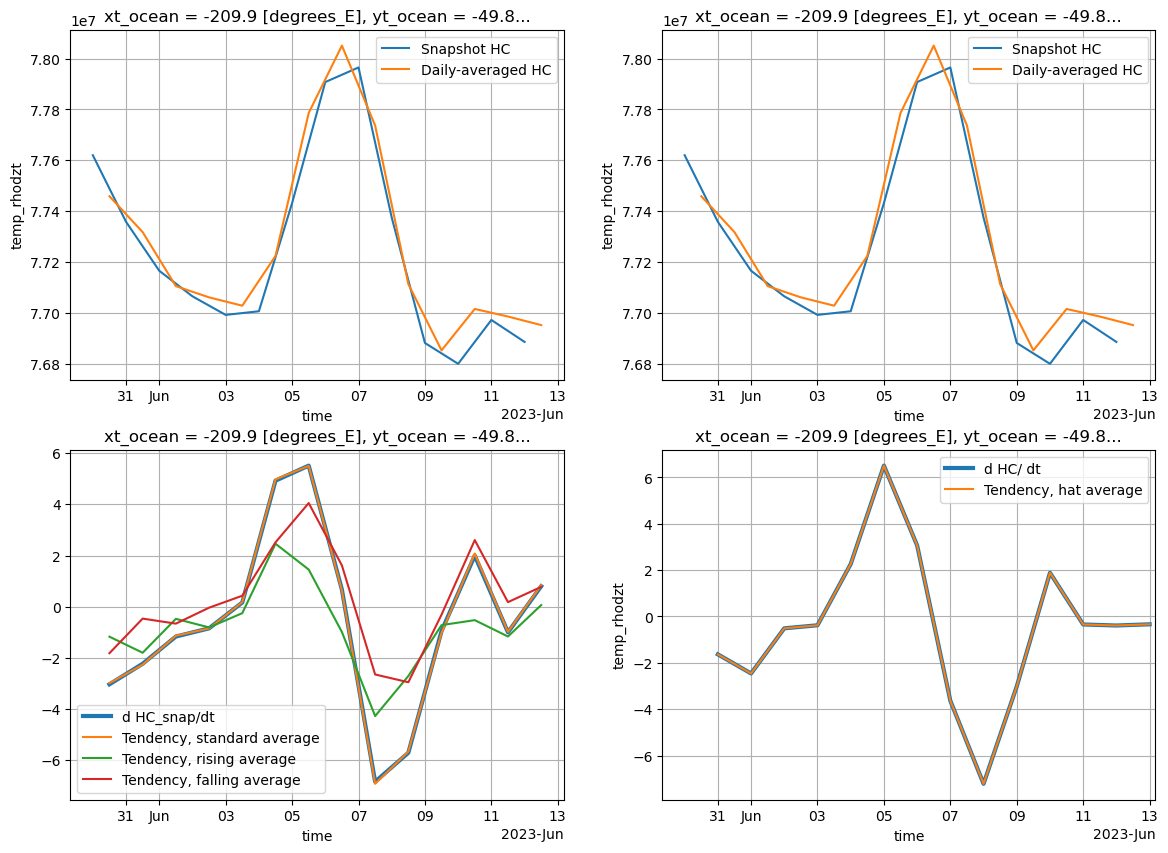

In [136]:
# Plot at a point
xt = 20
yt = 1
times = slice(0,14)

fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(14,10))

HC_snap.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[0][0],label='Snapshot HC')
HC.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[0][0],label='Daily-averaged HC')
HC_snap.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[0][1],label='Snapshot HC')
HC.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[0][1],label='Daily-averaged HC')

HC_snap_tend_from_HC.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[1][0],label='d HC_snap/dt',linewidth=3.)
HC_tend_from_HC.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[1][1],label='d HC/ dt',linewidth=3.)
HC_tend_hatavg.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[1][1],label='Tendency, hat average')
HC_tend_stavg.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[1][0],label='Tendency, standard average')
HC_tend_risavg.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[1][0],label='Tendency, rising average')
HC_tend_falavg.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[1][0],label='Tendency, falling average')
for ax in axes.reshape(-1):
    ax.grid()
    ax.set_xlim(axes[0][0].get_xlim())
    ax.legend()

Text(0.5, 1.0, 'Difference')

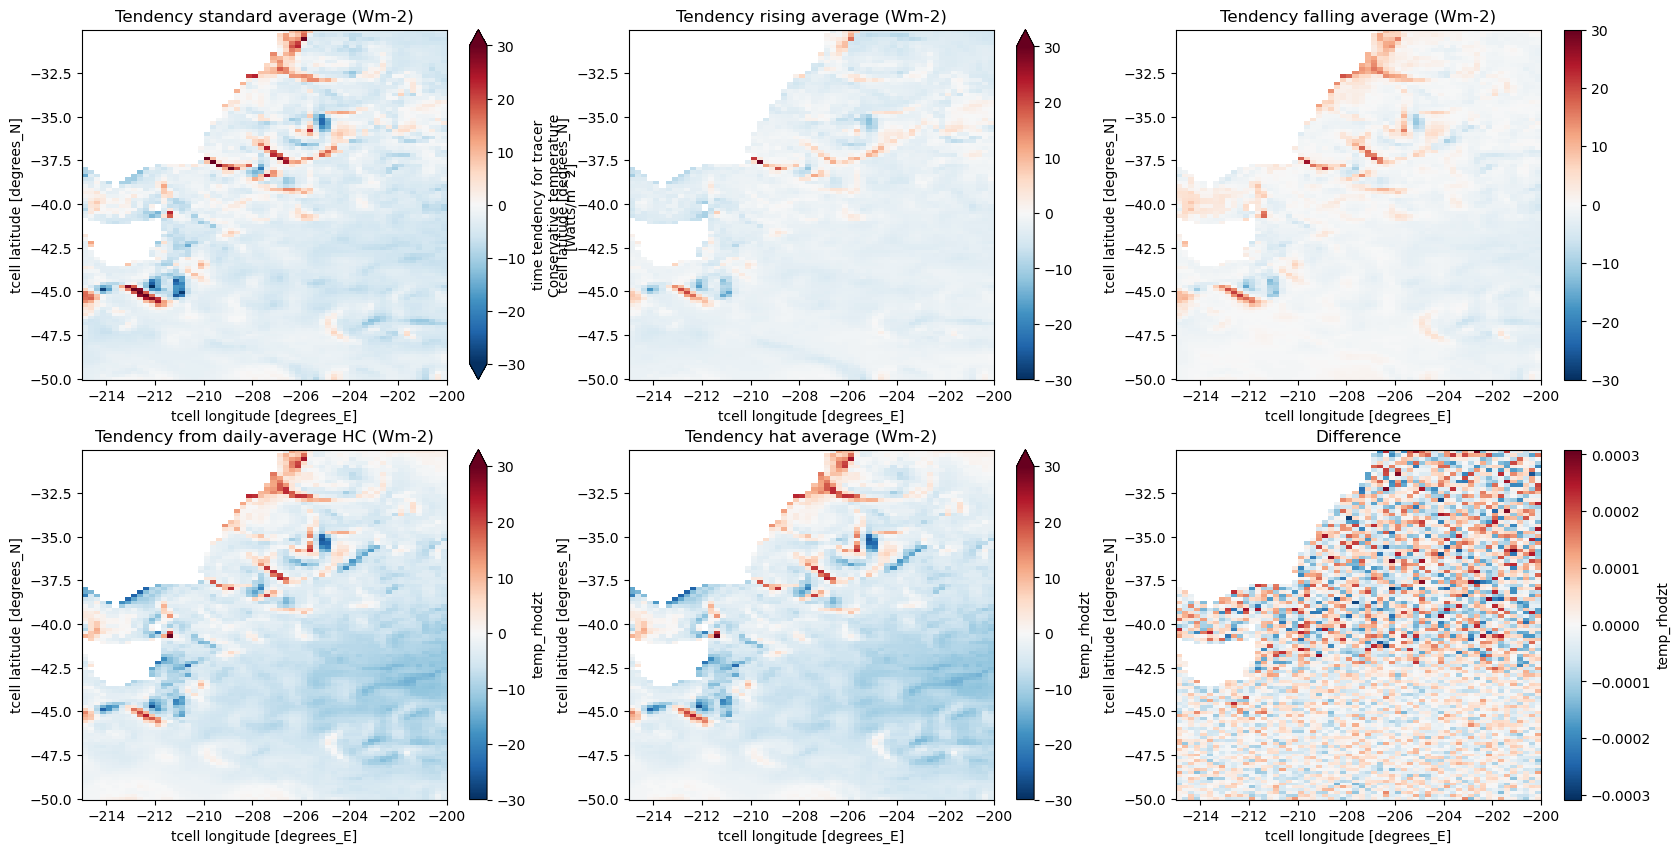

In [137]:
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(20,10))
index = 1

HC_tend_stavg.isel(time=index).plot(ax=axes[0][0],vmin=-30.,vmax=30.,cmap='RdBu_r')
axes[0][0].set_title('Tendency standard average (Wm-2)')
HC_tend_risavg.isel(time=index).plot(ax=axes[0][1],vmin=-30.,vmax=30.,cmap='RdBu_r')
axes[0][1].set_title('Tendency rising average (Wm-2)')
HC_tend_falavg.isel(time=index).plot(ax=axes[0][2],vmin=-30.,vmax=30.,cmap='RdBu_r')
axes[0][2].set_title('Tendency falling average (Wm-2)')
HC_tend_from_HC.isel(time=0).plot(ax=axes[1][0],vmin=-30.,vmax=30.,cmap='RdBu_r')
axes[1][0].set_title('Tendency from daily-average HC (Wm-2)')
HC_tend_hatavg.isel(time=0).plot(ax=axes[1][1],vmin=-30.,vmax=30.,cmap='RdBu_r')
axes[1][1].set_title('Tendency hat average (Wm-2)')
(HC_tend_from_HC - HC_tend_hatavg).isel(time=0).plot(ax=axes[1][2])
axes[1][2].set_title('Difference')

## Hat-averaging, combined-outputs epoch difference check

In [45]:
# single-output standard, rising and falling averages:
HC_tend_stavg = ds_day_budget.temp_tendency.isel(st_ocean=0)*(ds_day_budget.average_DT/np.timedelta64(1,'s')) # Short period standard difference (hence x DT)
HC_tend_falavg = ds_day_budget_falavg.temp_tendency.isel(st_ocean=0)                                        # Short period falling average difference (already x DT in code)
HC_tend_risavg = HC_tend_stavg - HC_tend_falavg                                                             # Short period rising average difference (standard - falling)

# Time-averaged heat content and its single-output tendency:
HC = ds_day_budget.temp_rhodzt.isel(st_ocean=0)*Cp
HC_tend_from_HC = HC.diff('time')/86400.
time_cen = [HC.time.isel(time=slice(x,x+2)).mean('time').values for x in range(len(HC.time))][:-1]
HC_tend_from_HC = HC_tend_from_HC.assign_coords({'time':time_cen})

In [102]:
# Define epoch periods:
epoch1 = list(range(10))
epoch2 = [len(HC.time) - 5 + x for x in range(5)]
epochM = np.arange(epoch1[-1]+1,epoch2[0],1)

n_minus_1_epoch1 = xr.DataArray(data=range(len(epoch1)),dims=['time'],coords={'time':HC_tend_stavg.time.isel(time=epoch1)}) # (n-1) for epoch1 as a DataArray
n_minus_1_epoch2 = xr.DataArray(data=range(len(epoch2)),dims=['time'],coords={'time':HC_tend_stavg.time.isel(time=epoch2)}) # (n-1) for epoch2 as a DataArray

# Compute epoch HC change from HC:
HC_change = HC.isel(time=epoch2).mean('time') - HC.isel(time=epoch1).mean('time') # All days have same length, so no weighted mean is needed

# Compute epoch HC change from hat average tendencies:
long_ris_epoch1 = HC_tend_risavg.isel(time=epoch1).mean('time') + (HC_tend_stavg.isel(time=epoch1)*n_minus_1_epoch1).mean('time')
long_sta_epoch1 = HC_tend_stavg.isel(time=epoch1).sum('time')
long_fal_epoch1 = long_sta_epoch1 - long_ris_epoch1

long_sta_epochM = HC_tend_stavg.isel(time=epochM).sum('time')

long_ris_epoch2 = HC_tend_risavg.isel(time=epoch2).mean('time') + (HC_tend_stavg.isel(time=epoch2)*n_minus_1_epoch2).mean('time')
long_sta_epoch2 = HC_tend_stavg.isel(time=epoch2).sum('time')
long_fal_epoch2 = long_sta_epoch2 - long_ris_epoch2

HC_change_from_hatavg = long_ris_epoch1 + long_sta_epochM + long_fal_epoch2

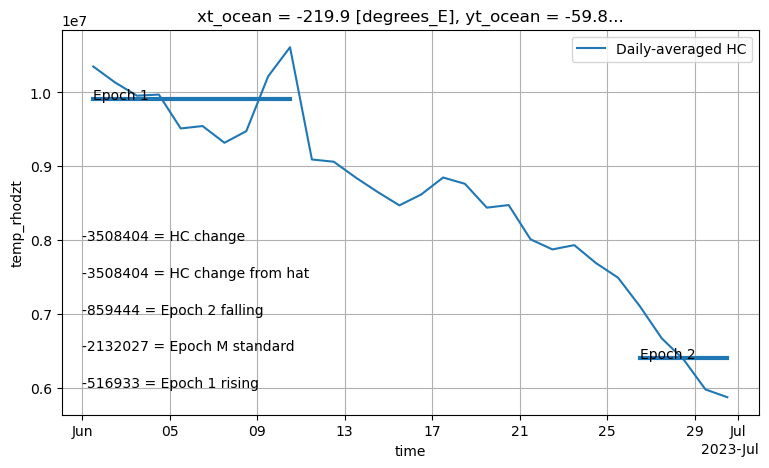

In [103]:
# Plot at a point
xt = 20
yt = 1
times = slice(0,len(HC.time))

fig = plt.figure(figsize=(9,5))
axes = [plt.gca()]

HC.isel(xt_ocean=xt,yt_ocean=yt,time=times).plot(ax=axes[0],label='Daily-averaged HC')
axes[0].plot(HC.time.isel(time=epoch1),HC.isel(xt_ocean=xt,yt_ocean=yt,time=epoch1).mean('time').values*xr.ones_like(HC.isel(xt_ocean=xt,yt_ocean=yt,time=epoch1)),linewidth=3.,color='C0')
axes[0].text(HC.time.isel(time=epoch1[0]),HC.isel(xt_ocean=xt,yt_ocean=yt,time=epoch1).mean('time').values,'Epoch 1')
axes[0].plot(HC.time.isel(time=epoch2),HC.isel(xt_ocean=xt,yt_ocean=yt,time=epoch2).mean('time').values*xr.ones_like(HC.isel(xt_ocean=xt,yt_ocean=yt,time=epoch2)),linewidth=3.,color='C0')
axes[0].text(HC.time.isel(time=epoch2[0]),HC.isel(xt_ocean=xt,yt_ocean=yt,time=epoch2).mean('time').values,'Epoch 2')

axes[0].text(np.datetime64('2023-06-01'),0.6e7,'%5.0f = Epoch 1 rising' % long_ris_epoch1.isel(xt_ocean=xt,yt_ocean=yt).values)
axes[0].text(np.datetime64('2023-06-01'),0.65e7,'%5.0f = Epoch M standard' % long_sta_epochM.isel(xt_ocean=xt,yt_ocean=yt).values)
axes[0].text(np.datetime64('2023-06-01'),0.7e7,'%5.0f = Epoch 2 falling' % long_fal_epoch2.isel(xt_ocean=xt,yt_ocean=yt).values)
axes[0].text(np.datetime64('2023-06-01'),0.75e7,'%5.0f = HC change from hat' % HC_change_from_hatavg.isel(xt_ocean=xt,yt_ocean=yt).values)
axes[0].text(np.datetime64('2023-06-01'),0.8e7,'%5.0f = HC change' % HC_change.isel(xt_ocean=xt,yt_ocean=yt).values)

for ax in axes:
    ax.grid()
    ax.set_xlim(axes[0].get_xlim())
    ax.legend()

Text(0.5, 1.0, 'Difference')

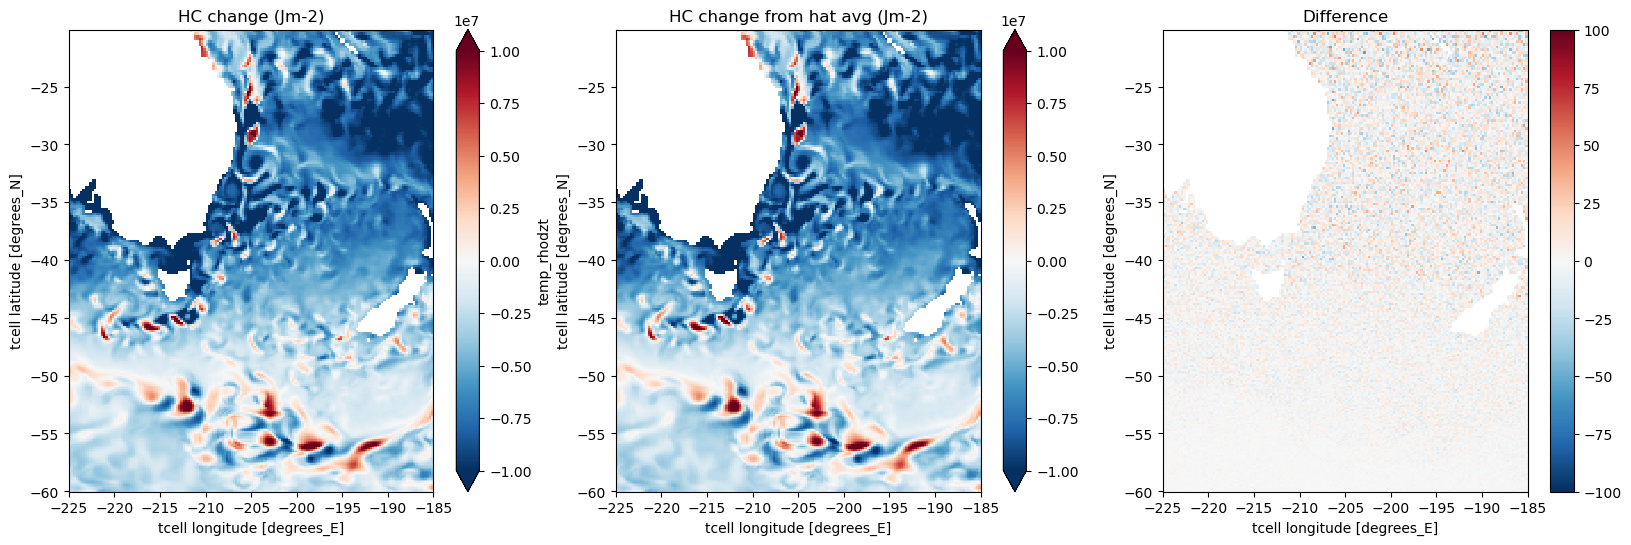

In [104]:
# Plot spatial slice:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(20,6))

HC_change.plot(ax=axes[0],vmin=-1.e7,vmax=1.e7,cmap='RdBu_r')
axes[0].set_title('HC change (Jm-2)')
HC_change_from_hatavg.plot(ax=axes[1],vmin=-1.e7,vmax=1.e7,cmap='RdBu_r')
axes[1].set_title('HC change from hat avg (Jm-2)')
(HC_change_from_hatavg-HC_change).plot(ax=axes[2],vmin=-1.e2,vmax=1.e2,cmap='RdBu_r')
axes[2].set_title('Difference')

##### Some old code from Chris that I probably don't need

In [84]:
# Use a hack of Chris's code to do the hatavg from tendency calculation:

# First, get times (in seconds):
time_stamp_file = base2 + 'time_stamp.out'

def init_run_time(time_stamp_file):
    with open(time_stamp_file, "r") as tstamp:
        tls = tstamp.readline().split()
        tls = [int(_) for _ in tls[:-1]]
        t0_date = datetime.datetime(tls[0], tls[1], tls[2], hour=tls[3], minute=tls[4], second=tls[5])
    time_units = datetime.datetime(1,1,1,0,0,0)
    return float((t0_date - time_units).total_seconds())

init_time = init_run_time(time_stamp_file)
init_times = init_time + (ds_day_budget.average_DT/np.timedelta64(1,'s')).cumsum() - 86400.
final_times = init_time + (ds_day_budget.average_DT/np.timedelta64(1,'s')).cumsum()

# Second,
# def compute_long_ris_avg_fwd(oheat_diag, ora_diag, monthly_avs, final_month_times):
#     """oheat_diag: time-average diagnostic
#     ora_diag: rising average diagnostic
#     monthly_avs: length of month
#     final month times: array of the last timestep of each averaging period (including timestep before run)"""
#     temp_tend_stnd_av = (oheat_diag*monthly_avs).sum('time')/(365*60*60*24) # 1/N * sum(std_av*month)
#     t_weight_av = ora_diag - oheat_diag*final_month_times 
#     t_weight_av_total = (t_weight_av*monthly_avs/(365*60*60*24)).sum('time') + final_month_times[-1]*temp_tend_stnd_av 
#     return t_weight_av_total

risavg_fwd_t0 = HC_tend_risavg.isel(time=0) - HC_tend_stavg.isel(time=0)*final_time.isel(time=0).values + final_time.isel(time=0).values*HC_tend_stavg.isel(time=0)
# def compute_long_ris_avg_bwd(oheat_diag, ora_diag, monthly_avs, initial_month_times):
#     """oheat_diag: time-average diagnostic
#     ora_diag: rising average diagnostic
#     monthly_avs: length of month
#     initial month times: array of the first timestep of each averaging period (including 1st timestep)"""
#     temp_tend_stnd_av = np.sum(oheat_diag*monthly_avs)/(365*60*60*24) # 1/N * sum(std_av*month)
#     t_weight_av = ora_diag + oheat_diag*initial_month_times # ris_avg + std_av*init_times
#     # m/N*(ris_avg + std_av*init_times) - t1*total_av
#     t_weight_av_total = np.sum(t_weight_av*monthly_avs/(365*60*60*24)) - initial_month_times[0]*temp_tend_stnd_av 
#     return t_weight_av_total

risavg_bwd_t1 = (HC_tend_risavg.isel(time=slice(0,2)) + HC_tend_stavg.isel(time=slice(0,2))*init_times.isel(time=slice(0,2))).mean('time') - init_times[-1]*HC_tend_stavg.isel(time=slice(0,2)).mean('time')


In [10]:
# Chris's code:
# compute long period rising average
def compute_long_ris_avg_fwd(oheat_diag, ora_diag, monthly_avs, final_month_times):
    """oheat_diag: time-average diagnostic
    ora_diag: rising average diagnostic
    monthly_avs: length of month
    final month times: array of the last timestep of each averaging period (including timestep before run)"""
    temp_tend_stnd_av = np.sum(oheat_diag*monthly_avs)/(365*60*60*24) # 1/N * sum(std_av*month)
    t_weight_av = ora_diag - oheat_diag*final_month_times 
    t_weight_av_total = np.sum(t_weight_av*monthly_avs/(365*60*60*24)) + final_month_times[-1]*temp_tend_stnd_av 
    return t_weight_av_total

def compute_long_ris_avg_bwd(oheat_diag, ora_diag, monthly_avs, initial_month_times):
    """oheat_diag: time-average diagnostic
    ora_diag: rising average diagnostic
    monthly_avs: length of month
    initial month times: array of the first timestep of each averaging period (including 1st timestep)"""
    temp_tend_stnd_av = np.sum(oheat_diag*monthly_avs)/(365*60*60*24) # 1/N * sum(std_av*month)
    t_weight_av = ora_diag + oheat_diag*initial_month_times # ris_avg + std_av*init_times
    # m/N*(ris_avg + std_av*init_times) - t1*total_av
    t_weight_av_total = np.sum(t_weight_av*monthly_avs/(365*60*60*24)) - initial_month_times[0]*temp_tend_stnd_av 
    return t_weight_av_total

def init_run_time(time_stamp_file):
    with open(time_stamp_file, "r") as tstamp:
        tls = tstamp.readline().split()
        tls = [int(_) for _ in tls[:-1]]
        t0_date = datetime.datetime(tls[0], tls[1], tls[2], hour=tls[3], minute=tls[4], second=tls[5])
    time_units = datetime.datetime(1,1,1,0,0,0)
    return float((t0_date - time_units).total_seconds())

# Construct online, ML-binned, budgets

## Define RHS term groups

In [9]:
bud_var_grps = {'advection':['temp_advection_in_mld',
                             'temp_submeso_in_mld',
                             'neutral_diffusion_in_mld_temp',
                             'neutral_gm_in_mld_temp',
                             'temp_vdiffuse_k33_in_mld'],
                'vert_mixing':['temp_nonlocal_KPP_in_mld',
                               'temp_vdiffuse_diff_cbt_in_mld'],
                'surface_flux':['temp_rivermix_in_mld',
                                'temp_vdiffuse_sbc_in_mld', 
                                'frazil_3d_in_mld',
                                'sfc_hflux_pme_in_mld',
                                'temp_eta_smooth_in_mld'], 
                'sw_pen':['sw_heat_in_mld']}

## Compute daily budget, standard averaging:

In [46]:
# Extract variable sums in groups, dividing by rho0*Cp to convert to degC/second
mlt_budget_stavg_online = (ds_day_budget['temp_tendency_in_mld']/rho0/Cp).rename('fixedh_tendency').to_dataset()
for var in bud_var_grps.keys():
    mlt_budget_stavg_online[var] = ds_day_budget[bud_var_grps[var][0]]/rho0/Cp
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            mlt_budget_stavg_online[var] += ds_day_budget[raw_var]/rho0/Cp

# Compute residual for check:
mlt_budget_stavg_online['residual'] = mlt_budget_stavg_online['fixedh_tendency'].copy(deep=True)
for var in list(mlt_budget_stavg_online.data_vars):
    mlt_budget_stavg_online['residual'] -= mlt_budget_stavg_online[var]

# Compute mlt tendency:
mlt_snap = (ds_day_snapshot.temp_in_mld/rho0).transpose(*mlt_budget_stavg_online['fixedh_tendency'].dims)
mlt_budget_stavg_online['mlt_tendency'] = xr.zeros_like(mlt_budget_stavg_online['fixedh_tendency']).copy(deep=True)
mlt_budget_stavg_online['mlt_tendency'].data = mlt_snap.isel(time=slice(1,None)).values - mlt_snap.isel(time=slice(0,-1)).values
mlt_budget_stavg_online['mlt_tendency'] = mlt_budget_stavg_online['mlt_tendency']/(ds_day_budget.average_DT/np.timedelta64(1,'s')) # Note: Depending on time decoding this line may change

# Entrainment term by residual:
mlt_budget_stavg_online['entrainment'] = -(mlt_budget_stavg_online['fixedh_tendency'] - mlt_budget_stavg_online['mlt_tendency'])

In [47]:
# Force computation:
mlt_budget_stavg_online.load();

## Compute monthly difference budget, standard averaging:

In [48]:
mlt_budget_stavg_online_monthly = (mlt_budget_stavg_online*(ds_day_budget.average_DT/np.timedelta64(1,'s'))).resample(time='1M').sum()
mlt_budget_stavg_online_monthly['time'] = mlt_budget_stavg_online.time.resample(time='1M').mean()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, 

## Compute daily budget, hat averaging:

In [13]:
def hat_average(st_avg,fal_avg_raw,average_DT):
    """
    Compute hat average from standard and falling average for a particular field
    """
    fal_avg = fal_avg_raw/(average_DT/np.timedelta64(1,'s')) # Fix integral -> mean by dividing by averaging period. We do this here to avoid loading all the variables just do do this fix.
    ris_avg = st_avg - fal_avg                               # Rising = standard - falling
    hat_avg = ris_avg.isel(time=slice(0,-1)).values +  fal_avg.isel(time=slice(1,None)) # Hat = rising over first day - falling over second day              
                                                                                        # Note: Dealing with time is done outside this function
    return(hat_avg)

In [14]:
# Extract variable sums in groups, dividing by rho0*Cp to convert to degC/second

# Template variable:
mlt_budget_hatavg_online = np.nan*xr.zeros_like(ds_day_snapshot.temp_in_mld.isel(time=slice(1,-1)).transpose(*ds_day_budget['temp_tendency_in_mld'].dims)) # Hat average tendencies lie on snapshots (1:end-1) time

# Compute hat average fixedh tendency:
mlt_budget_hatavg_online.data = hat_average(ds_day_budget['temp_tendency_in_mld'],ds_day_budget_falavg['temp_tendency_in_mld'],ds_day_budget_falavg.average_DT)/rho0/Cp

# Make a dataset:
mlt_budget_hatavg_online = mlt_budget_hatavg_online.rename('fixedh_tendency').to_dataset()

# Do other variables:
for var in bud_var_grps.keys():
    mlt_budget_hatavg_online[var] = xr.zeros_like(mlt_budget_hatavg_online['fixedh_tendency']).copy(deep=True)
    mlt_budget_hatavg_online[var].data = hat_average(ds_day_budget[bud_var_grps[var][0]],ds_day_budget_falavg[bud_var_grps[var][0]],ds_day_budget_falavg.average_DT)/rho0/Cp
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            mlt_budget_hatavg_online[var].data += hat_average(ds_day_budget[raw_var],ds_day_budget_falavg[raw_var],ds_day_budget_falavg.average_DT)/rho0/Cp

# Compute residual for check:
mlt_budget_hatavg_online['residual'] = mlt_budget_hatavg_online['fixedh_tendency'].copy(deep=True)
for var in list(mlt_budget_hatavg_online.data_vars):
    mlt_budget_hatavg_online['residual'] -= mlt_budget_hatavg_online[var]

# Compute mlt tendency:
mlt = (ds_day.temp_in_mld/rho0).transpose(*mlt_budget_hatavg_online['fixedh_tendency'].dims)
mlt_budget_hatavg_online['mlt_tendency'] = xr.zeros_like(mlt_budget_hatavg_online['fixedh_tendency']).copy(deep=True)
mlt_budget_hatavg_online['mlt_tendency'].data = mlt.isel(time=slice(1,None)).values - mlt.isel(time=slice(0,-1)).values
mlt_budget_hatavg_online['mlt_tendency'] = mlt_budget_hatavg_online['mlt_tendency']/86400. # Note: this will only work for daily averaging at the moment

# Entrainment term by residual:
mlt_budget_hatavg_online['entrainment'] = -(mlt_budget_hatavg_online['fixedh_tendency'] - mlt_budget_hatavg_online['mlt_tendency'])

## Compute monthly difference budget, hat averaging:

In [15]:
# Daily standard average budget (duplicated from above):
mlt_budget_stavg = (ds_day_budget['temp_tendency_in_mld']/rho0/Cp).rename('fixedh_tendency').to_dataset()
for var in bud_var_grps.keys():
    mlt_budget_stavg[var] = ds_day_budget[bud_var_grps[var][0]]/rho0/Cp
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            mlt_budget_stavg[var] += ds_day_budget[raw_var]/rho0/Cp

mlt_budget_stavg['residual'] = mlt_budget_stavg['fixedh_tendency'].copy(deep=True)
for var in list(mlt_budget_stavg.data_vars):
    mlt_budget_stavg['residual'] -= mlt_budget_stavg[var]

# Multiply by Delta t for differences:
mlt_budget_stavg = mlt_budget_stavg*(ds_day_budget.average_DT/np.timedelta64(1,'s'))

In [16]:
# Daily falling average budget:
mlt_budget_falavg = (ds_day_budget_falavg['temp_tendency_in_mld']/rho0/Cp).rename('fixedh_tendency').to_dataset()
for var in bud_var_grps.keys():
    mlt_budget_falavg[var] = ds_day_budget_falavg[bud_var_grps[var][0]]/rho0/Cp
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            mlt_budget_falavg[var] += ds_day_budget_falavg[raw_var]/rho0/Cp

mlt_budget_falavg['residual'] = mlt_budget_falavg['fixedh_tendency'].copy(deep=True)
for var in list(mlt_budget_falavg.data_vars):
    mlt_budget_falavg['residual'] -= mlt_budget_falavg[var]

In [17]:
# Daily rising average:
mlt_budget_risavg = mlt_budget_stavg - mlt_budget_falavg

In [18]:
# Define n-1 DataArrays for the months:
n_minus_1 = xr.DataArray(data=[x-1 for x in mlt_budget_risavg.time.dt.day.values],dims=['time'],coords={'time':mlt_budget_stavg.time})

# Monthly rising average:
mlt_budget_risavg_monthly = mlt_budget_risavg.resample(time='1ME').mean() + (mlt_budget_stavg*n_minus_1).resample(time='1ME').mean()

# Monthly standard average:
mlt_budget_stavg_monthly = mlt_budget_stavg.resample(time='1ME').sum()

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _va

In [19]:
# Define function to compute full budget given two months of interest:
def hat_difference(mlt_budget_risavg_monthly,mlt_budget_stavg_monthly,mlt_monthly,month1_index,month2_index):
    """
    Compute hat difference mlt budget from month 1 to month 2.
    """

    # List of variables:
    vars = list(mlt_budget_risavg_monthly.data_vars)

    # Interim months:
    monthM_index = np.arange(month1_index+1,month2_index,1)
    
    # Compute mlt difference as "mlt_tendency":
    mlt_budget_hat_diff = (mlt_monthly.isel(time=month2_index) - mlt_monthly.isel(time=month1_index)).rename('mlt_tendency').to_dataset()

    # Compute falling difference as difference between other budgets:
    mlt_budget_falavg_monthly = mlt_budget_stavg_monthly - mlt_budget_risavg_monthly

    # Compute budget terms:
    for var in vars:
        mlt_budget_hat_diff[var] = mlt_budget_risavg_monthly[var].isel(time=month1_index) + mlt_budget_stavg[var].isel(time=monthM_index).sum('time') + mlt_budget_falavg_monthly[var].isel(time=month2_index)

    # Compute entrainment by residual:
    mlt_budget_hat_diff['entrainment'] = -(mlt_budget_hat_diff['fixedh_tendency'] - mlt_budget_hat_diff['mlt_tendency'])

    return(mlt_budget_hat_diff)

## Region averaged time series:

In [21]:
sreg = [150-360,168-360,-44,-38] # Tasman Sea region from Kajtar et al. 2022

In [22]:
# climatology:
ds_clim1 = ds_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64('2017-01')+np.timedelta64(x,'M') for x in range(12)]})
ds_clim2 = ds_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64('2018-01')+np.timedelta64(x,'M') for x in range(12)]})
ds_climA = xr.concat([ds_clim1,ds_clim2],dim='time').resample(time='1D').interpolate("linear").sel(time=slice('2017-09-01','2017-12-31'))

/jobfs/133091540.gadi-pbs/ipykernel_2691483/1464910219.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_clim1 = ds_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64('2017-01')+np.timedelta64(x,'M') for x in range(12)]})
/jobfs/133091540.gadi-pbs/ipykernel_2691483/1464910219.py:3: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-

/jobfs/133091540.gadi-pbs/ipykernel_2691483/1651406806.py:14: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot([np.datetime64('2017-10-16T12:00:00'),np.datetime64('2017-12-16T12:00:00')],[Octavg.values,Decavg.values],'-',color='C0',linewidth=2.,linestyle='dashed',label='Epoch difference')
/jobfs/133091540.gadi-pbs/ipykernel_2691483/1651406806.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot([np.datetime64('2017-10-01'),np.datetime64('2017-12-31')],[mlt_snap.sel(time='2017-10-01',method='nearest'),mlt_snap.sel(time='2017-12-31',method='nearest')],'-',color='C1',linewidth=2.,linestyle='dotted',label='Snapshot difference')


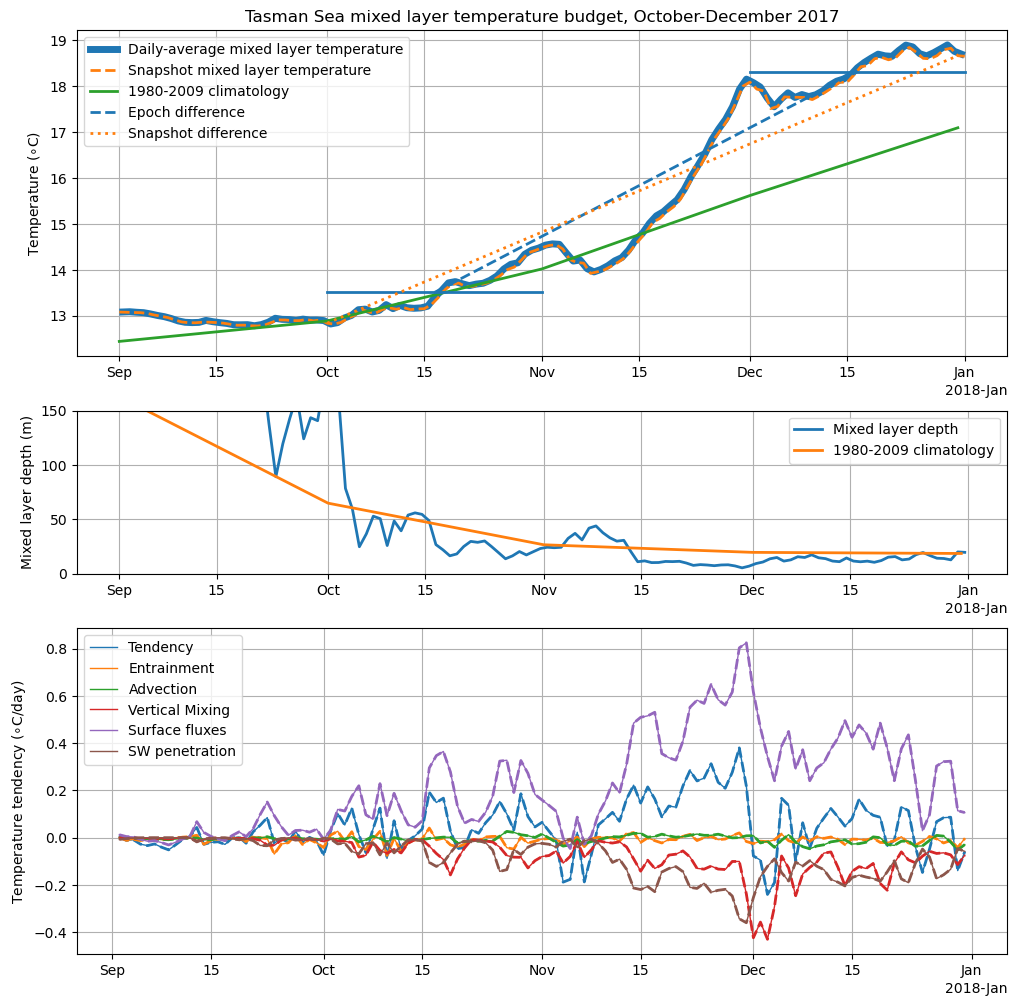

In [54]:
fig, axes = plt.subplots(nrows=3,ncols=1,figsize=(12,12),height_ratios=[1.,0.5,1.])

mlt = (ds_day.temp_in_mld/rho0).sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])
mlt_snap = (ds_day_snapshot.temp_in_mld/rho0).sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])
mlt.plot(ax=axes[0],label='Daily-average mixed layer temperature',linewidth=5.)
mlt_snap.plot(ax=axes[0],label='Snapshot mixed layer temperature',linewidth=2.,linestyle='dashed')
(ds_climA.temp_in_mld/rho0).plot(ax=axes[0],label='1980-2009 climatology',linewidth=2.)

# Plot some averages:
Octavg = mlt.sel(time=slice('2017-10-01','2017-10-31')).mean('time')
Decavg = mlt.sel(time=slice('2017-12-01','2017-12-31')).mean('time')
axes[0].plot([np.datetime64('2017-10-01'),np.datetime64('2017-11-01')],[Octavg.values,Octavg.values],'-',color='C0',linewidth=2.)
axes[0].plot([np.datetime64('2017-12-01'),np.datetime64('2018-01-01')],[Decavg.values,Decavg.values],'-',color='C0',linewidth=2.)
axes[0].plot([np.datetime64('2017-10-16T12:00:00'),np.datetime64('2017-12-16T12:00:00')],[Octavg.values,Decavg.values],'-',color='C0',linewidth=2.,linestyle='dashed',label='Epoch difference')
axes[0].plot([np.datetime64('2017-10-01'),np.datetime64('2017-12-31')],[mlt_snap.sel(time='2017-10-01',method='nearest'),mlt_snap.sel(time='2017-12-31',method='nearest')],'-',color='C1',linewidth=2.,linestyle='dotted',label='Snapshot difference')


axes[0].legend()
axes[0].set_title('Tasman Sea mixed layer temperature budget, October-December 2017')
axes[0].set_ylabel('Temperature ($\circ$C)')
axes[0].grid()

ds_day.mld.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).plot(ax=axes[1],linewidth=2.,label='Mixed layer depth')
(ds_climA.mld).plot(ax=axes[1],label='1980-2009 climatology',linewidth=2.)
axes[1].set_ylabel('Mixed layer depth (m)')
axes[1].grid()
axes[1].legend()
axes[1].set_ylim([0.,150.])

vars = ['mlt_tendency','entrainment','advection','vert_mixing','surface_flux','sw_pen']
labels = ['Tendency','Entrainment','Advection','Vertical Mixing','Surface fluxes','SW penetration']

budget_stavg = mlt_budget_hatavg_online.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])
budget_hatavg = mlt_budget_hatavg_online.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])
unit_conv = 86400

for j, var in enumerate(vars):
    (budget_stavg[var]*unit_conv).plot(ax=axes[2],color='C' + str(j),linewidth=1.,label=labels[j]) 
    (budget_hatavg[var]*unit_conv).plot(ax=axes[2],color='C' + str(j),linewidth=2.,linestyle='dashed')
axes[2].legend()
axes[2].set_ylabel('Temperature tendency ($\circ$C/day)')
axes[2].grid()

for ax in axes:
    ax.set_xlabel('')
    
plt.savefig('MLT_budget_TasmanSea_OctDec2017_time_series.png',dpi=250,bbox_inches='tight')

## Spatial plots of time-averaged budgets:

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'


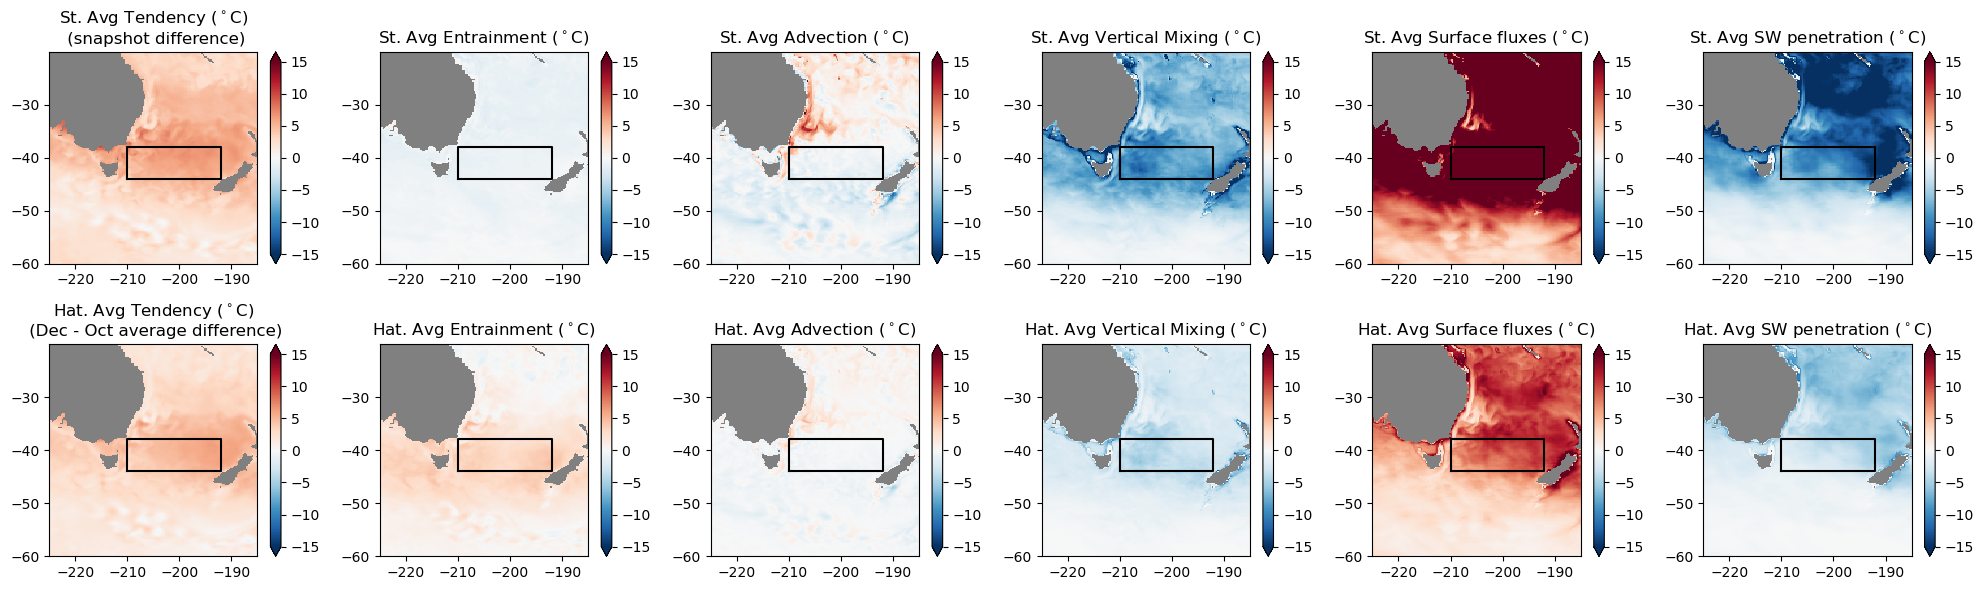

In [55]:
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20,6))
axs = axes.reshape(-1)

vars = ['mlt_tendency','entrainment','advection','vert_mixing','surface_flux','sw_pen']
labels = ['Tendency','Entrainment','Advection','Vertical Mixing','Surface fluxes','SW penetration']
clim = 15

# Standard budget difference terms averaged over 3 month period (equivalent to snapshot difference):
times = slice('2017-10-01','2017-12-31')
stavg_budget = mlt_budget_stavg_online_monthly.sel(time=times).sum('time')

for j, var in enumerate(vars):
    stavg_budget[var].where(stavg_budget[var]!=0.).plot(ax=axes[0][j],cmap='RdBu_r',vmin=-clim,vmax=clim,extend='both',cbar_kwargs={'label':''}) 
    axes[0][j].set_title('St. Avg ' + labels[j] + ' ($^\circ$C)')
axes[0][0].set_title(axes[0][0].get_title() + '\n (snapshot difference)')

# Hat average budget difference terms between 1st and last month (equivalent to time-average difference):
mlt_monthly = (ds_day.temp_in_mld/rho0).resample(time='1M').mean()
hatavg_budget = hat_difference(mlt_budget_risavg_monthly.sel(time=times),mlt_budget_stavg_monthly.sel(time=times),mlt_monthly.sel(time=times),0,len(mlt_budget_risavg_monthly.time.sel(time=times))-1)

for j, var in enumerate(vars):
    hatavg_budget[var].plot(ax=axes[1][j],cmap='RdBu_r',vmin=-clim,vmax=clim,extend='both',cbar_kwargs={'label':''}) 
    axes[1][j].set_title('Hat. Avg ' + labels[j] + ' ($^\circ$C)')
axes[1][0].set_title(axes[1][0].get_title() + '\n (Dec - Oct average difference)')

for ax in axs:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor([0.5,0.5,0.5])
    ax.plot([sreg[0],sreg[1],sreg[1],sreg[0],sreg[0]],[sreg[2],sreg[2],sreg[3],sreg[3],sreg[2]],'-k')
    
plt.tight_layout()
plt.savefig('MLT_budget_TasmanSea_OctDec2017_spatial.png',dpi=250,bbox_inches='tight')

# Compare offline and online budgets (needs updating)

## Define function to compute offline mixed layer temperature budget

In [53]:
def compute_mixed_layer_temperature_budget_offline(ds_budget,ds_budget_2d,mld,dzt):
    """
    Compute mixed layer temperature budget

    Inputs:
    ds_budget -> dataset containing time-averaged 3D budget quantities
    ds_budget_2d -> dataset containing time-averaged 2D (surface layer only) budget quantities (these are just added in without summing)
    mld -> dataarray containing time-averaged mixed layer depth
    dzt -> datarray containing time-averaged grid cell thicknesses
    temp_mld_snap -> datarray containing snapshots of temp*rho0*dzt summed over mld
    mld_snap -> dataarray containing snapshots of mld

    Outputs:
    ds_budget_in_mld -> dataset containing all the "internal" (i.e. not including mlt tendency and entrainment) terms in the diagnosed mixed layer temperature budget (2D), in units of degC/second
    """

    # Sum over mixed layer:
    ds_budget_in_mld = ds_budget.isel(st_ocean=0,drop=True).copy(deep=True)
    for ti in tqdm(range(len(ds_budget.time))):
        dzt_ti = dzt.isel(time=ti).load()
        dzt_ti_bot = dzt_ti.cumsum('st_ocean')
        ds_budget_ti = ds_budget.isel(time=ti).load()
        mld_ti = mld.isel(time=ti).load()
        for var in list(ds_budget_in_mld.data_vars):
            ds_budget_in_mld[var][ti,:,:] = ds_budget_ti[var].where(dzt_ti_bot<mld_ti).sum('st_ocean')
            for k in range(len(ds_budget_ti.st_ocean)-1):
                ds_budget_in_mld[var][ti,:,:] += xr.where(np.logical_and(dzt_ti_bot[k,:,:]>mld_ti,dzt_ti_bot[k+1,:,:]<mld_ti),((mld_ti-dzt_ti_bot[k,:,:])/dzt_ti[k,:,:])*ds_budget_ti[var][k,:,:],0.)
            ds_budget_in_mld[var][ti,:,:] = ds_budget_in_mld[var][ti,:,:]/rho0/Cp/mld_ti
            # Units: Wm-2/kg*m3/J*kg*degC/m = degC/sec

    # Add 2D surface layer variables:
    for var in list(ds_budget_2d.data_vars):
        ds_budget_in_mld[var] = (ds_budget_2d[var]/rho0/Cp/mld).load()

    # Compute residual for check:
    ds_budget_in_mld['residual'] = ds_budget_in_mld['temp_tendency'] - ds_budget_in_mld[list(ds_budget_in_mld.data_vars)[1:]].to_array().sum('variable')
        
    return(ds_budget_in_mld)

## Compute daily and monthly offline binned mixed layer temperature budgets

In [72]:
# Offline budget terms grouping:
bud_var_grps = {'temp_advection':['temp_advection','temp_submeso','temp_vdiffuse_k33','neutral_diffusion_temp','neutral_gm_temp'],
                'temp_vert_mixing':['temp_vdiffuse_diff_cbt','temp_nonlocal_KPP'],
                'temp_sbc':['temp_vdiffuse_sbc','frazil_3d','temp_rivermix'],
                'temp_sw_pen':['sw_heat']}
bud_2d_vars = ['temp_eta_smooth','sfc_hflux_pme']

In [73]:
# Add a few terms that are in ds_month in the monthly output:
ds_mon_budget['sw_heat'] = ds_month['sw_heat']
ds_mon_budget['sfc_hflux_pme'] = ds_month['sfc_hflux_pme']
ds_mon_budget['temp_rivermix'] = ds_month['temp_rivermix']

# Group terms:
ds_mon_budget_reduced = ds_mon_budget['temp_tendency'].to_dataset().copy(deep=True)
ds_day_budget_reduced = ds_day_budget['temp_tendency'].to_dataset().copy(deep=True)
for var in bud_var_grps.keys():
    ds_mon_budget_reduced[var] = ds_mon_budget[bud_var_grps[var][0]]
    ds_day_budget_reduced[var] = ds_day_budget[bud_var_grps[var][0]]
    if (len(bud_var_grps[var])>1):
        for raw_var in bud_var_grps[var][1:]:
            ds_mon_budget_reduced[var] += ds_mon_budget[raw_var]
            ds_day_budget_reduced[var] += ds_day_budget[raw_var]

ds_mon_budget_reduced_2d = ds_mon_budget[bud_2d_vars]
ds_day_budget_reduced_2d = ds_day_budget[bud_2d_vars]

In [75]:
# Do monthly computation:
mon_budget_in_mld = compute_mixed_layer_temperature_budget_offline(ds_mon_budget_reduced,ds_mon_budget_reduced_2d,ds_month.mld,ds_month.dht)
# Add 2D vars to sbc term:
for var in bud_2d_vars:
    mon_budget_in_mld['temp_sbc'] += mon_budget_in_mld[var]
    mon_budget_in_mld = mon_budget_in_mld.drop_vars([var])

compute_mlt_entrainment(mon_budget_in_mld,ds_mon_snapshot.temp_in_mld/rho0,ds_mon_budget.average_DT)
# Save to file:
mon_budget_in_mld.to_netcdf('/g/data/e14/rmh561/mlt_budget_temporary/mon_budget_temp_om2_omip2_extension_output372.nc')

100%|██████████| 1/1 [00:03<00:00,  3.68s/it]


In [76]:
# Do daily computation:
day_budget_in_mld = compute_mixed_layer_temperature_budget_offline(ds_day_budget_reduced,ds_day_budget_reduced_2d,ds_day.mld,ds_day.dzt)
# Add 2D vars to sbc term:
for var in bud_2d_vars:
    day_budget_in_mld['temp_sbc'] += day_budget_in_mld[var]
    day_budget_in_mld = day_budget_in_mld.drop_vars([var])

compute_mlt_entrainment(day_budget_in_mld,ds_day_snapshot.temp_in_mld/rho0,ds_day_budget.average_DT)
# Save to file:
day_budget_in_mld.to_netcdf('/g/data/e14/rmh561/mlt_budget_temporary/day_budget_temp_om2_omip2_extension_output372.nc')

100%|██████████| 30/30 [02:26<00:00,  4.88s/it]


In [77]:
# Load from file:
mon_budget_in_mld = xr.open_dataset('/g/data/e14/rmh561/mlt_budget_temporary/mon_budget_temp_om2_omip2_extension_output372.nc').isel(time=0,drop=True)
day_budget_in_mld = xr.open_dataset('/g/data/e14/rmh561/mlt_budget_temporary/day_budget_temp_om2_omip2_extension_output372.nc').mean('time')

#### Spatial plots comparing monthly, daily offline and online:

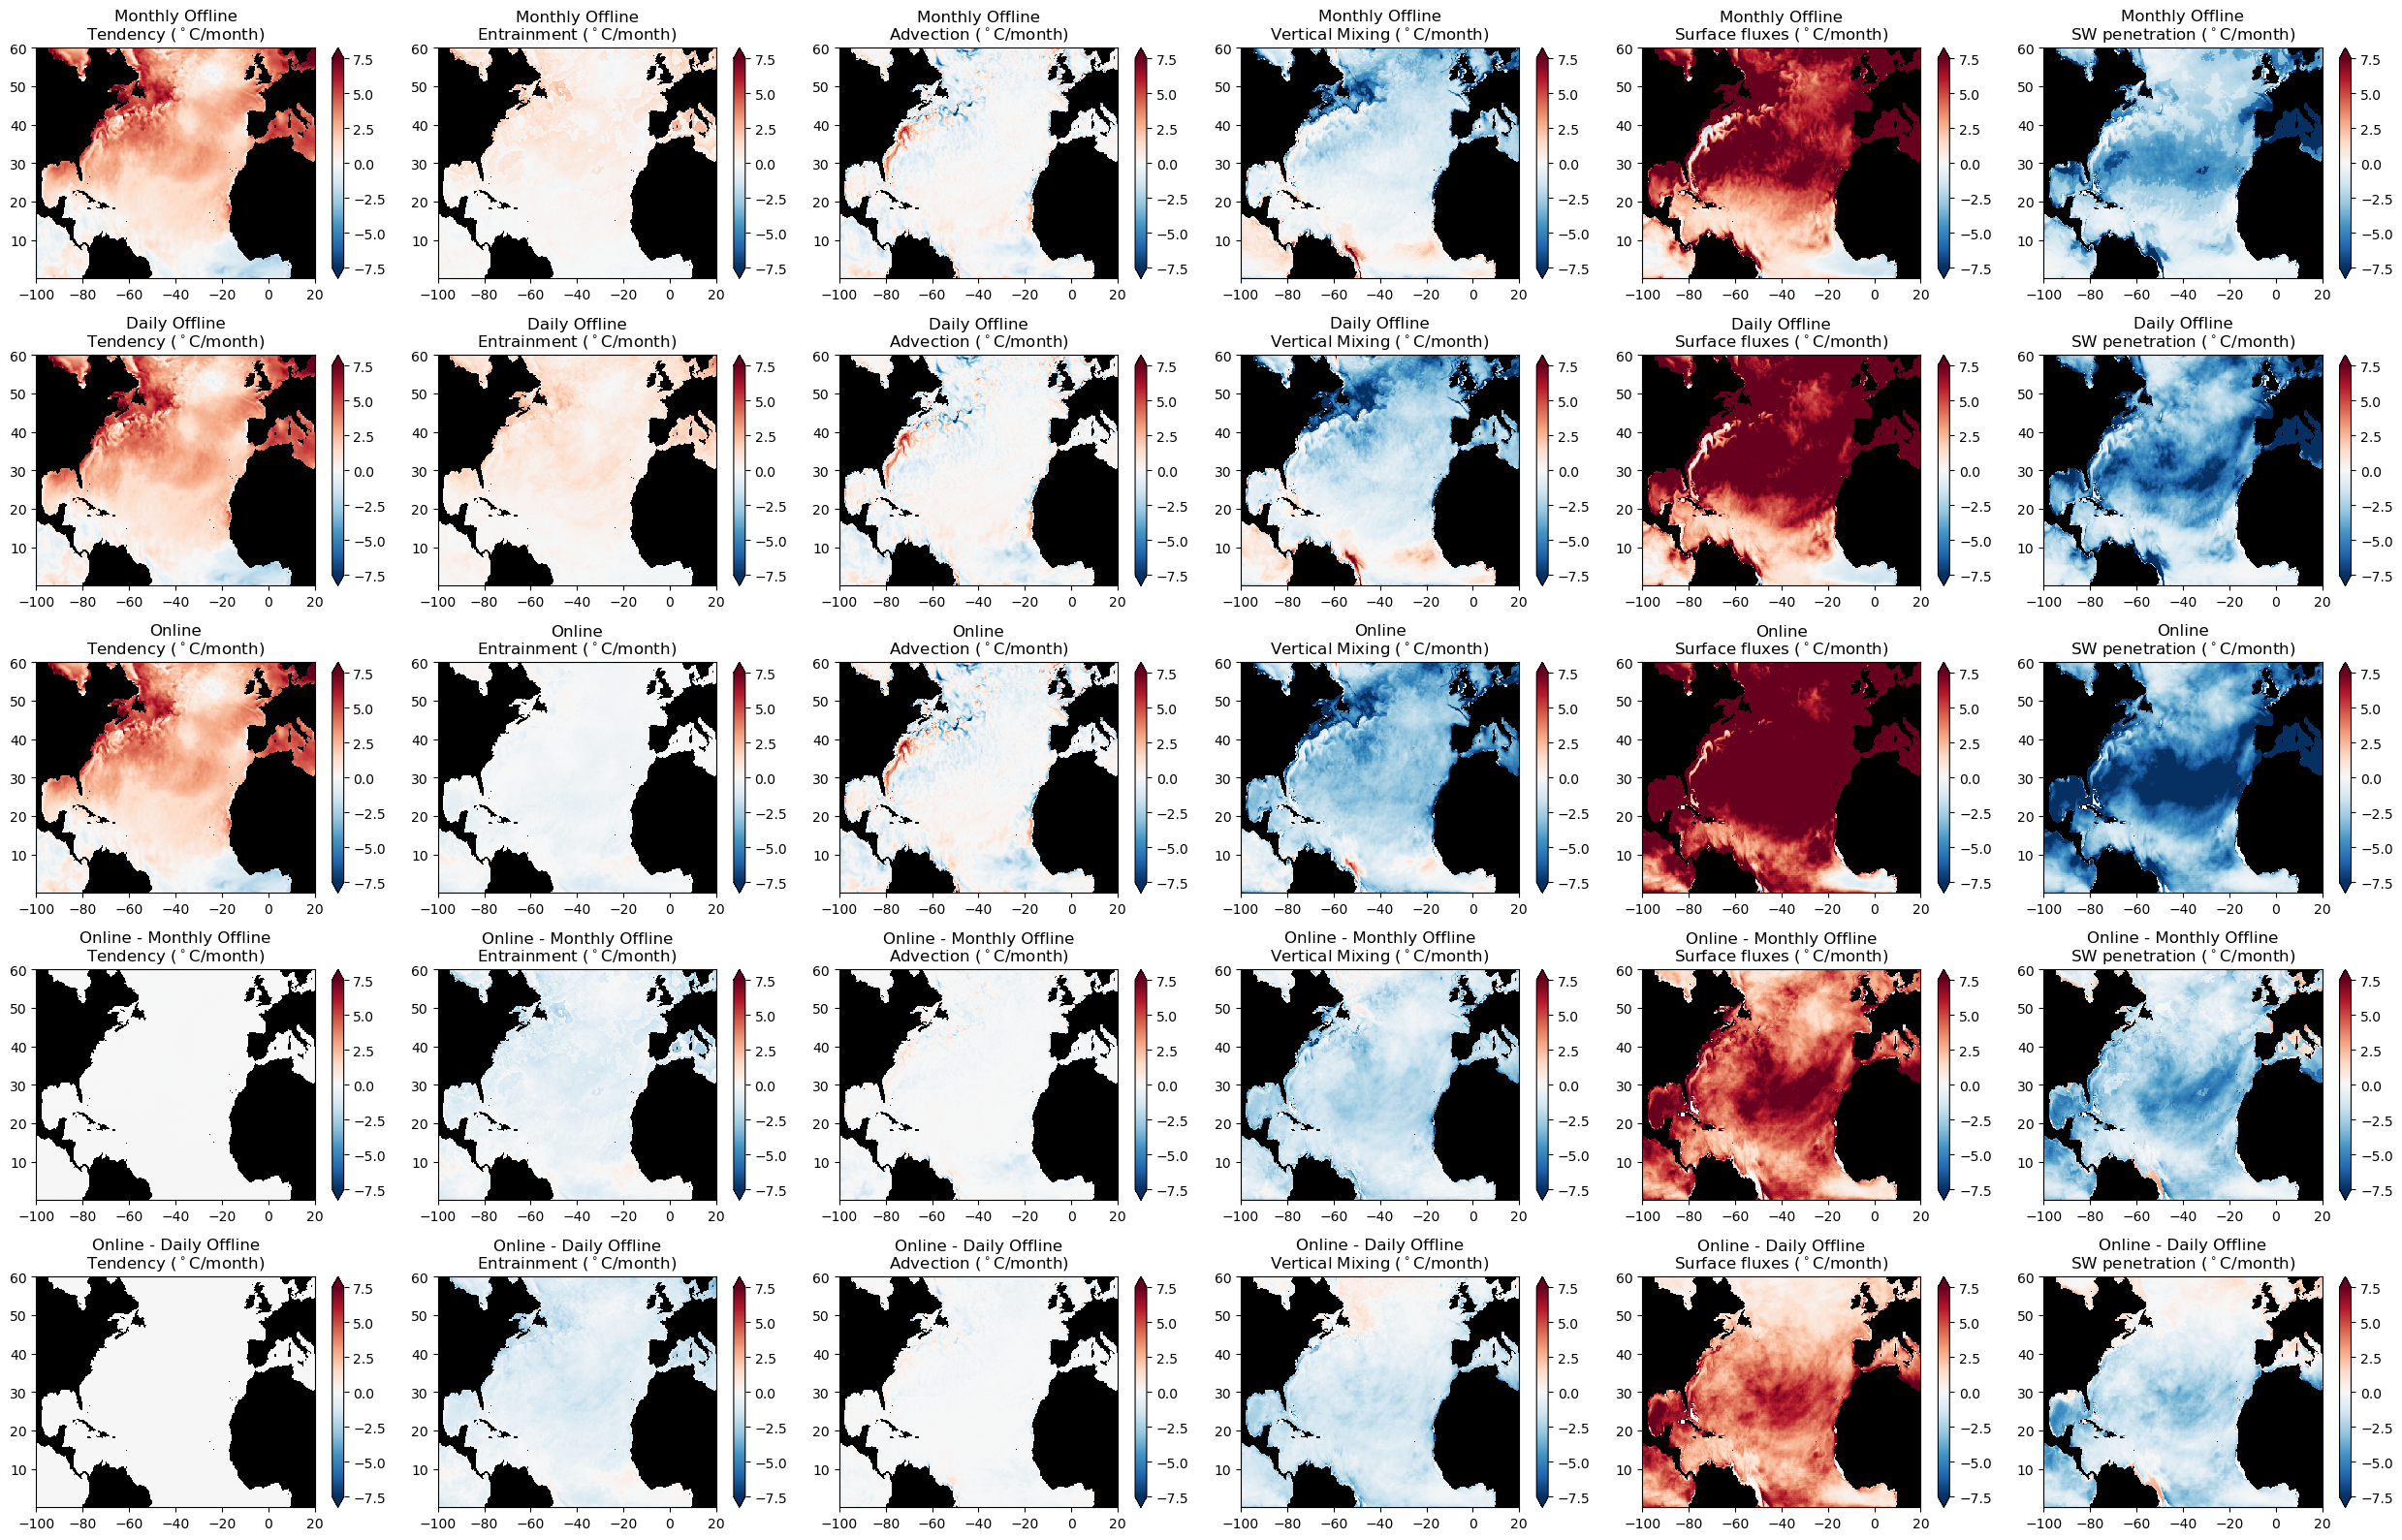

In [81]:
fig, axs = plt.subplots(nrows=5, ncols=6, figsize=(25,16))

vars = ['mlt_tendency','entrainment','temp_advection','temp_vert_mixing','temp_sbc','temp_sw_pen']
labels = ['Tendency','Entrainment','Advection','Vertical Mixing','Surface fluxes','SW penetration']
budgets = [mon_budget_in_mld,day_budget_in_mld,online_budget_in_mld,online_budget_in_mld - mon_budget_in_mld,online_budget_in_mld - day_budget_in_mld]
budget_labels = ['Monthly Offline','Daily Offline','Online','Online - Monthly Offline','Online - Daily Offline']
unit_conv = 86400*30.5
clim = 7.5

for i in range(len(budgets)):
    for j, var in enumerate(vars):
        (budgets[i][var]*unit_conv).plot(ax=axs[i][j],cmap='RdBu_r',vmin=-clim,vmax=clim,extend='both',cbar_kwargs={'label':''}) 
        axs[i][j].set_title(budget_labels[i] + '\n' + labels[j] + ' ($^\circ$C/month)')

for ax in axs.reshape(-1):
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('k')
plt.tight_layout()
plt.savefig('MLT_budget_Atlantic_Jun_2023_Online_Offline_Comparison.png',dpi=250)